#### Introduction


Banks and other financial institutions play a crucial role in the economy by providing loans to individuals and businesses. However, a significant risk for these institutions is loan default, where borrowers fail to repay their loans. To mitigate this risk, financial institutions increasingly leverage machine learning to predict loan defaults and make informed lending decisions.
#### Project Goals
This project aims to build a machine learning model that can accurately predict loan defaults. This model will help financial institutions:
Identify High-Risk Borrowers: By predicting the likelihood of default, lenders can identify borrowers who may pose a higher risk. This allows for early intervention and potentially prevents defaults altogether.
Implement Targeted Interventions: Once high-risk borrowers are identified, lenders can implement targeted strategies such as loan restructuring or financial counseling to help them repay their loans.
Make Informed Loan Decisions: The model's predictions will inform loan decisions, potentially reducing the overall risk exposure for financial institutions.

#### Data Acquisition
We will be using a loan default prediction dataset from Kaggle here. This dataset was originally from Coursera: here. The data provides a sufficient number of data points to train and build a robust machine learning model.

#### Model Development
Our goal is to build a binary classification model that can predict whether a borrower will default on their loan (1) or not (0). We will explore various machine learning algorithms to develop a model with high accuracy and interpretability.

In [1]:
# Importing the Neccessary Libraries

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import (train_test_split, 
                                     cross_val_score, 
                                     RandomizedSearchCV, 
                                     GridSearchCV)

from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.pipeline import Pipeline,make_pipeline
from sklearn.compose import ColumnTransformer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import VotingClassifier

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import (accuracy_score, 
                             f1_score, 
                             precision_score, 
                             recall_score, 
                             RocCurveDisplay,
                             precision_recall_curve, 
                             average_precision_score,
                             roc_auc_score, 
                             roc_curve, auc)

from sklearn.neighbors import NearestCentroid
import xgboost as xgb
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

import time
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Loading the Dataframe

data = pd.read_csv("E:\ml\Loan_default.csv")
data.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  object 
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  object 
 11  EmploymentType  255347 non-null  object 
 12  MaritalStatus   255347 non-null  object 
 13  HasMortgage     255347 non-null  object 
 14  HasDependents   255347 non-null  object 
 15  LoanPurpose     255347 non-null  object 
 16  HasCoSigner     255347 non-null  object 
 17  Default   

In [4]:
data.describe()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default
count,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000
mean,43.498306,82499.304597,127578.865512,574.264346,59.541976,2.501036,13.492773,36.025894,0.500212,0.116128
std,14.990258,38963.013729,70840.706142,158.903867,34.643376,1.117018,6.636443,16.969330,0.230917,0.320379
min,18.000000,15000.000000,5000.000000,300.000000,0.000000,1.000000,2.000000,12.000000,0.100000,0.000000
25%,31.000000,48825.500000,66156.000000,437.000000,30.000000,2.000000,7.770000,24.000000,0.300000,0.000000
50%,43.000000,82466.000000,127556.000000,574.000000,60.000000,2.000000,13.460000,36.000000,0.500000,0.000000
75%,56.000000,116219.000000,188985.000000,712.000000,90.000000,3.000000,19.250000,48.000000,0.700000,0.000000
max,69.000000,149999.000000,249999.000000,849.000000,119.000000,4.000000,25.000000,60.000000,0.900000,1.000000


In [5]:
data.isnull().sum()

LoanID            0
Age               0
Income            0
LoanAmount        0
CreditScore       0
MonthsEmployed    0
NumCreditLines    0
InterestRate      0
LoanTerm          0
DTIRatio          0
Education         0
EmploymentType    0
MaritalStatus     0
HasMortgage       0
HasDependents     0
LoanPurpose       0
HasCoSigner       0
Default           0
dtype: int64

In [6]:
data.duplicated().sum()

np.int64(0)

Observation:

It appears that our data does not have any null values

Neither are there any duplicated values in our data sets

In [7]:
data.dtypes

LoanID             object
Age                 int64
Income              int64
LoanAmount          int64
CreditScore         int64
MonthsEmployed      int64
NumCreditLines      int64
InterestRate      float64
LoanTerm            int64
DTIRatio          float64
Education          object
EmploymentType     object
MaritalStatus      object
HasMortgage        object
HasDependents      object
LoanPurpose        object
HasCoSigner        object
Default             int64
dtype: object

In [8]:
data.columns.values

array(['LoanID', 'Age', 'Income', 'LoanAmount', 'CreditScore',
       'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm',
       'DTIRatio', 'Education', 'EmploymentType', 'MaritalStatus',
       'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner',
       'Default'], dtype=object)

In [9]:
categorical_variables=['Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 
                       'HasDependents', 'LoanPurpose','NumCreditLines', 'HasCoSigner', 'Default']


numerical_variables=['Age', 'Income', 'LoanAmount', 'CreditScore', 
                     'MonthsEmployed', 'InterestRate', 'LoanTerm', 'DTIRatio',]

In [10]:
#For checking errors in categorical variables.
for variable in categorical_variables:
    print(data[variable].value_counts())
    print("~"*50)

Education
Bachelor's     64366
High School    63903
Master's       63541
PhD            63537
Name: count, dtype: int64
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
EmploymentType
Part-time        64161
Unemployed       63824
Self-employed    63706
Full-time        63656
Name: count, dtype: int64
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
MaritalStatus
Married     85302
Divorced    85033
Single      85012
Name: count, dtype: int64
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
HasMortgage
Yes    127677
No     127670
Name: count, dtype: int64
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
HasDependents
Yes    127742
No     127605
Name: count, dtype: int64
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
LoanPurpose
Business     51298
Home         51286
Education    51005
Other        50914
Auto         50844
Name: count, dtype: int64
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
NumCreditLines
2    64130
3    63834
4    63829
1    63554
Name: count, dtype: i

This loop checks every categorical column, counts how many times each category appears, and prints the results. It helps you identify spelling mistakes, inconsistent labels, unexpected categories, and other errors before performing data analysis or building a machine learning model.

From these `value_counts()` outputs, we can draw several useful insights about the dataset.

### 1. Education

```
Bachelor's     64366
High School    63903
Master's       63541
PhD            63537
```

**Insights:**

* The four education levels are almost equally distributed.
* There are no spelling mistakes or unexpected categories.
* The dataset is balanced with respect to education, so no education group is overrepresented.

---

### 2. EmploymentType

```
Part-time        64161
Unemployed       63824
Self-employed    63706
Full-time        63656
```

**Insights:**

* All employment types have nearly the same number of observations.
* No missing or incorrect category names are visible.
* This balanced distribution is useful for unbiased model training.

---

### 3. MaritalStatus

```
Married     85302
Divorced    85033
Single      85012
```

**Insights:**

* The three marital status categories are almost perfectly balanced.
* No unexpected values such as "Widowed" or misspellings are present.
* Data quality appears good.

---

### 4. HasMortgage

```
Yes    127677
No     127670
```

**Insights:**

* The variable is perfectly balanced between "Yes" and "No".
* This is ideal for machine learning since both classes are equally represented.

---

### 5. HasDependents

```
Yes    127742
No     127605
```

**Insights:**

* Almost equal numbers of people have and do not have dependents.
* No obvious data entry errors.

---

### 6. LoanPurpose

```
Business     51298
Home         51286
Education    51005
Other        50914
Auto         50844
```

**Insights:**

* All five loan purposes have nearly equal frequencies.
* No dominant loan purpose exists.
* Categories are clean and consistent.

---

### 7. NumCreditLines

```
2    64130
3    63834
4    63829
1    63554
```

**Insights:**

* Customers are almost evenly distributed across having 1–4 credit lines.
* This variable does not appear skewed.
* Since these values represent ordered categories (1, 2, 3, 4), it may be treated as an ordinal or numerical feature depending on the analysis.

---

### 8. HasCoSigner

```
Yes    127701
No     127646
```

**Insights:**

* Nearly equal numbers of applicants have and do not have a co-signer.
* This feature is balanced.

---

### 9. Default (Target Variable)

```
0    225694
1     29653
```

**Insights:**

* The target variable is **highly imbalanced**.
* Approximately:

  * **No Default (0):** 225,694 (**88.4%**)
  * **Default (1):** 29,653 (**11.6%**)
* Most customers did **not** default on their loans.
* This imbalance is important because a machine learning model may become biased toward predicting the majority class.

**Possible approaches to handle this imbalance include:**

* Oversampling the minority class (e.g., SMOTE)
* Undersampling the majority class
* Using class weights
* Evaluating the model with metrics such as Precision, Recall, F1-score, and ROC-AUC instead of relying only on Accuracy.

---

# Overall Insights

* ✅ All categorical variables have **clean and consistent categories** with no apparent spelling mistakes or unexpected values.
* ✅ Most predictor variables are **well balanced**, which is beneficial for exploratory data analysis and model training.
* ✅ There are **no obvious data quality issues** in the categorical features.
* ⚠️ The **target variable (`Default`) is significantly imbalanced (88.4% vs. 11.6%)**, which should be addressed during model building to avoid biased predictions.


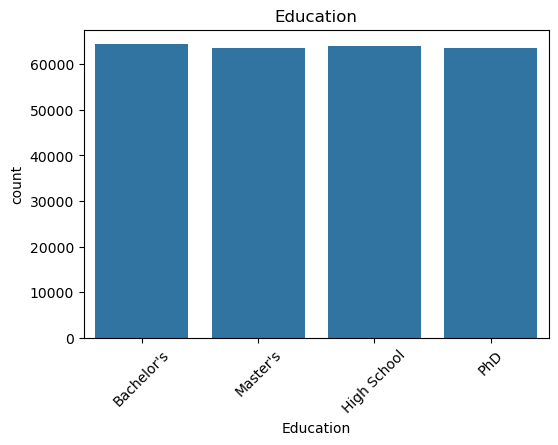

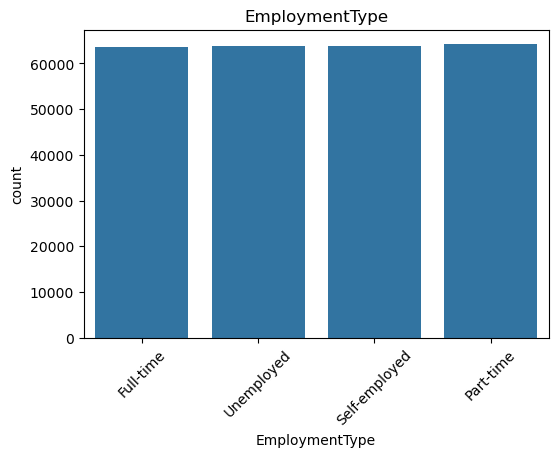

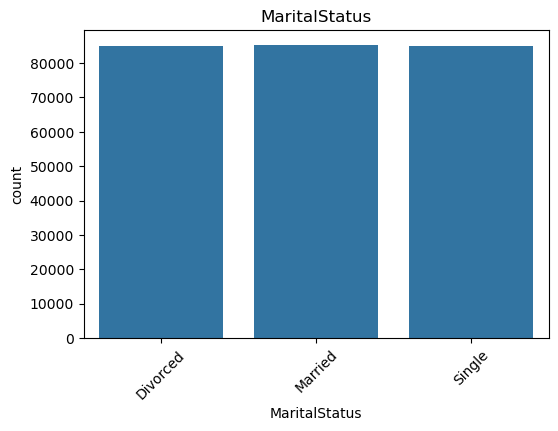

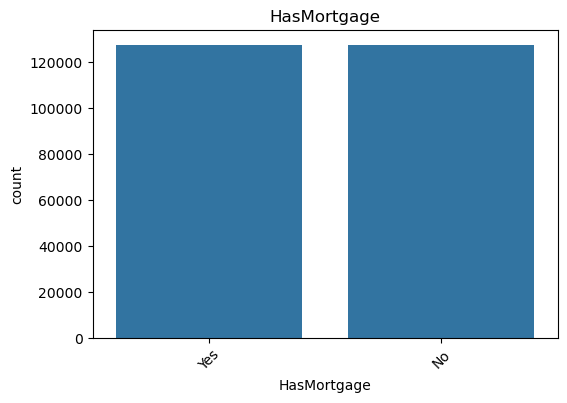

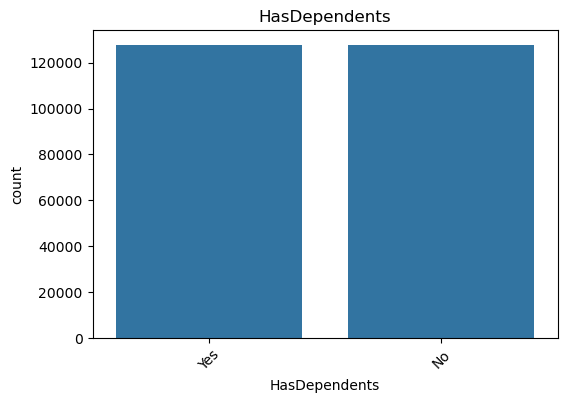

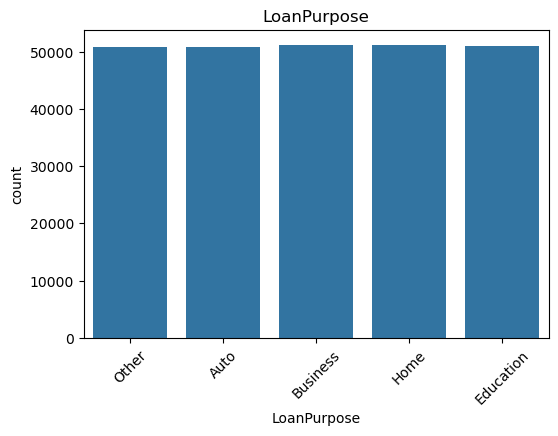

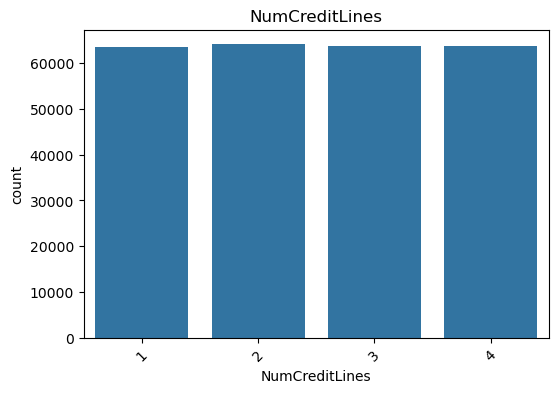

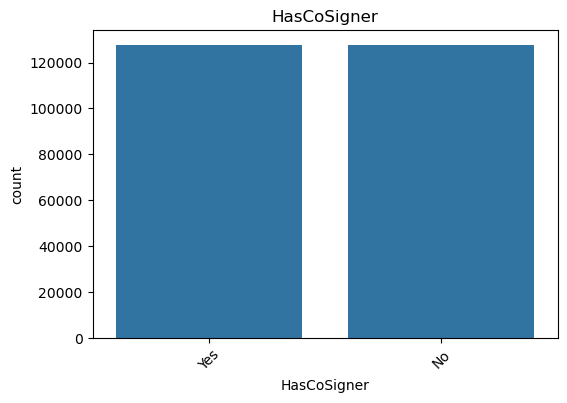

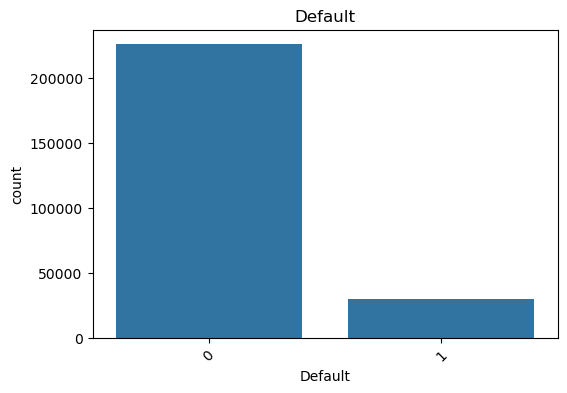

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

for variable in categorical_variables:
    plt.figure(figsize=(6,4))
    sns.countplot(x=variable, data=data)
    plt.xticks(rotation=45)
    plt.title(variable)
    plt.show()

### Relationship with the Target Variable

In [12]:
for variable in categorical_variables:
    print(pd.crosstab(data[variable],data['Default'],normalize='index')*100)
    print("~"*50)

Default              0          1
Education                        
Bachelor's   87.898891  12.101109
High School  87.121105  12.878895
Master's     89.128279  10.871721
PhD          89.414042  10.585958
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Default                 0          1
EmploymentType                      
Full-time       90.536634   9.463366
Part-time       88.034787  11.965213
Self-employed   88.537971  11.462029
Unemployed      86.447105  13.552895
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Default                0          1
MaritalStatus                      
Divorced       87.467219  12.532781
Married        89.602823  10.397177
Single         88.087564  11.912436
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Default              0          1
HasMortgage                      
No           87.654892  12.345108
Yes          89.119419  10.880581
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Default                0          1
HasDependents     

These tables show the **percentage of customers who defaulted (`1`) and did not default (`0`) within each category**. This is much more informative than simple frequency counts because it helps identify which groups are at higher risk of default.

Here are the key insights you can include in your EDA report.

---

# 1. Education

| Education   | Default Rate |
| ----------- | -----------: |
| Bachelor's  |   **12.10%** |
| High School |   **12.88%** |
| Master's    |   **10.87%** |
| PhD         |   **10.59%** |

### Insights

* Applicants with **High School education** have the **highest default rate (12.88%)**.
* Applicants with a **PhD** have the **lowest default rate (10.59%)**.
* Default rates generally **decrease as education level increases**, suggesting higher education may be associated with better loan repayment behavior.

---

# 2. Employment Type

| Employment    | Default Rate |
| ------------- | -----------: |
| Full-time     |    **9.46%** |
| Part-time     |   **11.97%** |
| Self-employed |   **11.46%** |
| Unemployed    |   **13.55%** |

### Insights

* **Unemployed applicants** have the highest default rate (**13.55%**).
* **Full-time employees** have the lowest default rate (**9.46%**).
* Employment status appears to be a strong predictor of loan default.

---

# 3. Marital Status

| Status   | Default Rate |
| -------- | -----------: |
| Divorced |   **12.53%** |
| Single   |   **11.91%** |
| Married  |   **10.40%** |

### Insights

* **Divorced applicants** have the highest default rate.
* **Married applicants** have the lowest default rate.
* Being married may be associated with greater financial stability.

---

# 4. Has Mortgage

| Mortgage | Default Rate |
| -------- | -----------: |
| No       |   **12.35%** |
| Yes      |   **10.88%** |

### Insights

* Applicants **without a mortgage** default more frequently.
* Those with a mortgage may have a stronger credit history or greater financial responsibility.

---

# 5. Has Dependents

| Dependents | Default Rate |
| ---------- | -----------: |
| No         |   **12.72%** |
| Yes        |   **10.50%** |

### Insights

* Applicants **without dependents** have a higher default rate.
* Although it might seem counterintuitive, this suggests applicants with dependents in this dataset are more financially responsible.

---

# 6. Loan Purpose

| Purpose   | Default Rate |
| --------- | -----------: |
| Business  |   **12.33%** |
| Auto      |   **11.88%** |
| Education |   **11.84%** |
| Other     |   **11.79%** |
| Home      |   **10.23%** |

### Insights

* **Business loans** have the highest default rate.
* **Home loans** have the lowest default rate.
* Loan purpose has some influence, although the differences are smaller than for employment type.

---

# 7. Number of Credit Lines

| Credit Lines | Default Rate |
| ------------ | -----------: |
| 1            |   **10.52%** |
| 2            |   **11.06%** |
| 3            |   **11.92%** |
| 4            |   **12.94%** |

### Insights

* Default rate **increases as the number of credit lines increases**.
* Applicants with **four credit lines** have the highest default rate.
* Having more active credit lines may indicate higher debt exposure.

---

# 8. Has Co-Signer

| Co-Signer | Default Rate |
| --------- | -----------: |
| No        |   **12.87%** |
| Yes       |   **10.36%** |

### Insights

* Applicants **without a co-signer** default more often.
* Having a co-signer appears to reduce default risk.

---

# 9. Default vs Default

```text
Default
0 -> 100%
1 -> 100%
```

This table compares the target variable with itself, so it is expected to show a perfect match. It **does not provide any useful insight** and can be ignored.

---

# Overall Findings

From these analyses, the variables that appear to have the strongest relationship with loan default are:

| Feature            | Observation                                                                                                      |
| ------------------ | ---------------------------------------------------------------------------------------------------------------- |
| **EmploymentType** | Unemployed applicants have the highest default rate (13.55%), while full-time employees have the lowest (9.46%). |
| **NumCreditLines** | Default rate increases steadily from 10.52% (1 credit line) to 12.94% (4 credit lines).                          |
| **HasCoSigner**    | Applicants without a co-signer are more likely to default (12.87% vs. 10.36%).                                   |
| **Education**      | Higher education levels are associated with lower default rates.                                                 |
| **MaritalStatus**  | Married applicants have the lowest default rate.                                                                 |
| **HasMortgage**    | Mortgage holders default less frequently than non-holders.                                                       |
| **HasDependents**  | Applicants with dependents show a lower default rate.                                                            |
| **LoanPurpose**    | Business loans have the highest default rate, while home loans have the lowest.                                  |

### Suggested next step

To determine whether these observed differences are **statistically significant** rather than due to chance, perform a **Chi-square test of independence** for each categorical feature against the `Default` variable. This will help identify which categorical variables have a significant association with loan default and are likely to be useful predictors in your model.


In [13]:
from scipy.stats import chi2_contingency


for variable in categorical_variables:
    
    # Create contingency table
    contingency_table = pd.crosstab(data[variable], data['Default'])

    # Perform Chi-square test
    chi2, p, dof, expected = chi2_contingency(contingency_table)

    print(f"{variable}")
    print(f"Chi-square Statistic : {chi2:.3f}")
    print(f"P-value              : {p:.5f}")
    print(f"Degrees of Freedom   : {dof}")

    if p < 0.05:
        print("Decision: Reject H0")
        print(f"Conclusion: {variable} is significantly associated with Default.")
    else:
        print("Decision: Fail to Reject H0")
        print(f"Conclusion: {variable} is NOT significantly associated with Default.")

    print("-"*60)

Education
Chi-square Statistic : 214.019
P-value              : 0.00000
Degrees of Freedom   : 3
Decision: Reject H0
Conclusion: Education is significantly associated with Default.
------------------------------------------------------------
EmploymentType
Chi-square Statistic : 529.745
P-value              : 0.00000
Degrees of Freedom   : 3
Decision: Reject H0
Conclusion: EmploymentType is significantly associated with Default.
------------------------------------------------------------
MaritalStatus
Chi-square Statistic : 200.361
P-value              : 0.00000
Degrees of Freedom   : 2
Decision: Reject H0
Conclusion: MaritalStatus is significantly associated with Default.
------------------------------------------------------------
HasMortgage
Chi-square Statistic : 133.252
P-value              : 0.00000
Degrees of Freedom   : 1
Decision: Reject H0
Conclusion: HasMortgage is significantly associated with Default.
------------------------------------------------------------
HasDepende

For your **loan default prediction** dataset, you want to test whether each **categorical variable is associated with the target variable (`Default`)**. The appropriate test is the **Chi-Square Test of Independence**.

## Hypotheses

For each categorical variable (e.g., `Education`, `EmploymentType`, `MaritalStatus`), the hypotheses are:

### Null Hypothesis ((H_0))

There is **no significant association** between the categorical feature and the loan default status (`Default`).

In other words, the two variables are **independent**.

Example for Education:

> **H₀:** Education and Default are independent. Education has no significant effect on loan default.

---

### Alternative Hypothesis ((H_1))

There **is a significant association** between the categorical feature and the loan default status (`Default`).

In other words, the two variables are **dependent**.

Example for Education:

> **H₁:** Education and Default are associated. Education has a significant effect on loan default.

---

## Decision Rule

* If **p-value < 0.05**

  * Reject **H₀**
  * Conclude that there is a **significant association** between the feature and `Default`.

* If **p-value ≥ 0.05**

  * Fail to reject **H₀**
  * Conclude that there is **no significant association** between the feature and `Default`.



### Outlier detection

In [14]:
for variable in numerical_variables:
    Q1 = data[variable].quantile(0.25)
    Q3 = data[variable].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_count = data[
        (data[variable] < lower_bound) |
        (data[variable] > upper_bound)
    ].shape[0]

    print(f"{variable}: {outlier_count} outliers ({outlier_count / len(data) * 100:.2f}%)")

Age: 0 outliers (0.00%)
Income: 0 outliers (0.00%)
LoanAmount: 0 outliers (0.00%)
CreditScore: 0 outliers (0.00%)
MonthsEmployed: 0 outliers (0.00%)
InterestRate: 0 outliers (0.00%)
LoanTerm: 0 outliers (0.00%)
DTIRatio: 0 outliers (0.00%)


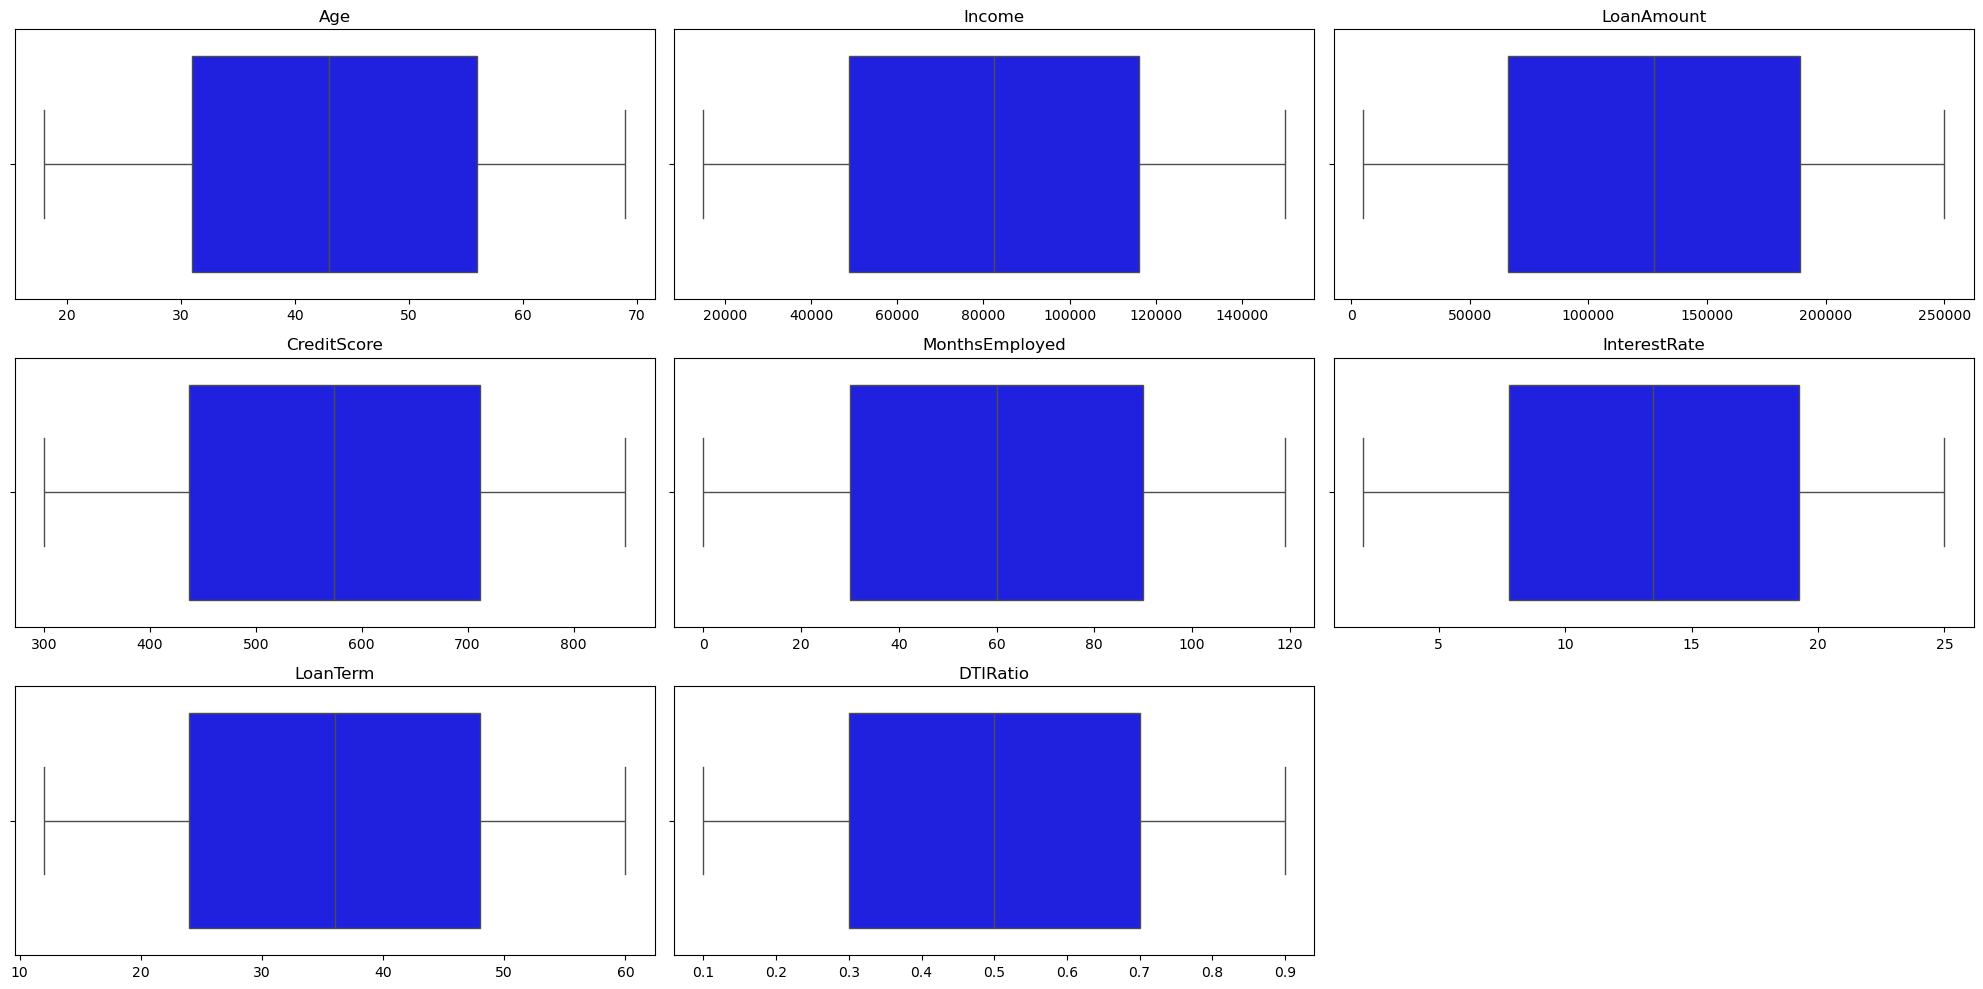

In [15]:
plt.figure(figsize=(20, 10))
ind=1
for  variable in (numerical_variables):
    plt.subplot(3, 3, ind)
    sns.boxplot(x=data[variable],color="blue")
    plt.title(variable)
    ind+=1
    plt.xlabel('')
plt.tight_layout()
plt.show()

Observation :

There is no such data skewness or outliers is seen in the numerical data.

The dataset is free from outliers and skewness so it is ready to build a machine learning model

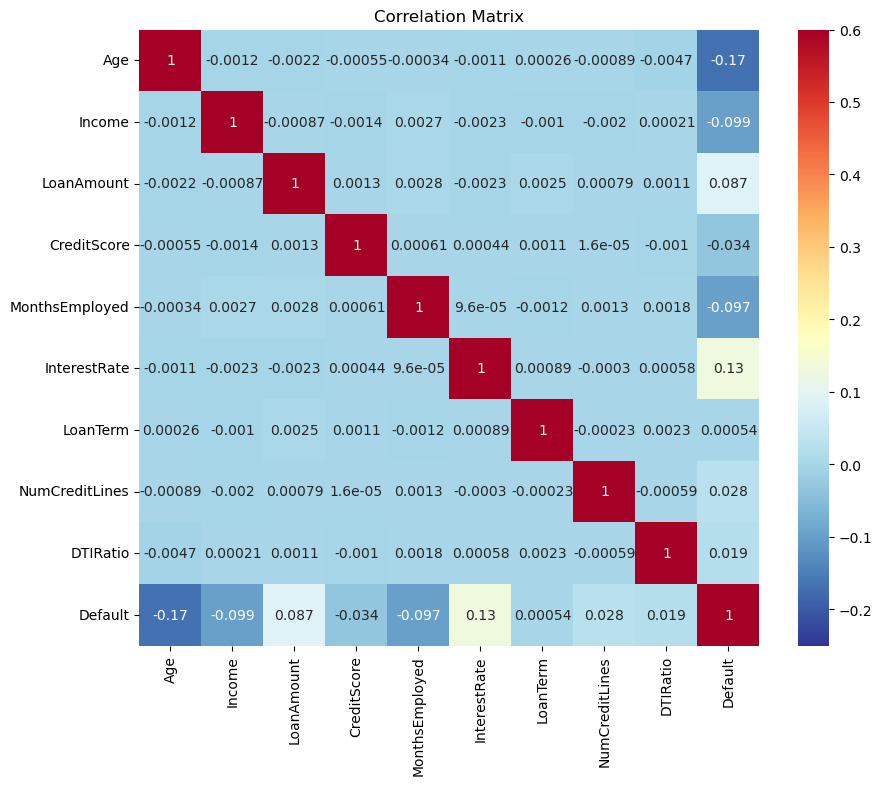

In [16]:
# Correlation Heatmap (Numerical Columns)

plt.figure(figsize=(10, 8))
sns.heatmap(data[['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'InterestRate', 'LoanTerm',
                'NumCreditLines' ,'DTIRatio',"Default"]].corr(), cmap = plt.cm.RdYlBu_r, vmin = -0.25, annot=True, vmax = 0.6)
plt.title('Correlation Matrix')
plt.show()

The key concept is this:

### Pearson Correlation

* Measures the **strength of a linear relationship** between two variables.
* It assumes that the data points follow a straight-line trend.
* If the relationship is curved (e.g., U-shaped, exponential, logarithmic), Pearson correlation can be close to **0**, even though the variables are strongly related.

**Example:**

* As interest rate increases, default risk increases steadily.
* This is a linear relationship, so Pearson correlation will capture it well.

---

### Spearman Correlation

* Measures the **strength of a monotonic relationship**.
* It is based on the **rank (order)** of the values, not their actual values.
* It detects relationships where one variable consistently increases or decreases with the other, even if the relationship is not a straight line.

**Example:**

* As age increases, default risk decreases rapidly at first and then levels off.
* The relationship is curved, but the direction is always decreasing.
* Pearson may underestimate this relationship, while Spearman captures it better.

---

### When does a nonlinear relationship exist?

A nonlinear relationship exists when the change in one variable does **not** produce a constant change in the other.

Examples of nonlinear relationships:

* Quadratic (U-shaped or inverted U)
* Exponential
* Logarithmic
* Sigmoid (S-shaped)

---

### Comparing Pearson and Spearman

* **Pearson ≈ Spearman** → Relationship is likely **linear**.
* **Spearman > Pearson** (or much different) → Relationship is likely **nonlinear but monotonic**.
* **Both are near 0** → There may be **no relationship**, or the relationship may be **non-monotonic** (e.g., U-shaped), which neither correlation measures well.

### In simple terms

* **Pearson asks:** "Can I fit a straight line through these points?"
* **Spearman asks:** "Do the values generally move in the same direction, regardless of the shape of the curve?"

That's why a feature can have **low Pearson correlation** but still be **important** in prediction—it may have a **nonlinear relationship** with the target.


In [17]:
for feature in numerical_variables:
    pearson = data[feature].corr(data['Default'], method='pearson')
    spearman = data[feature].corr(data['Default'], method='spearman')

    print(f"{feature}")
    print(f"Pearson : {pearson:.3f}")
    print(f"Spearman: {spearman:.3f}")
    print()

Age
Pearson : -0.168
Spearman: -0.168

Income
Pearson : -0.099
Spearman: -0.099

LoanAmount
Pearson : 0.087
Spearman: 0.087

CreditScore
Pearson : -0.034
Spearman: -0.034

MonthsEmployed
Pearson : -0.097
Spearman: -0.097

InterestRate
Pearson : 0.131
Spearman: 0.131

LoanTerm
Pearson : 0.001
Spearman: 0.001

DTIRatio
Pearson : 0.019
Spearman: 0.019



In [18]:
from sklearn.feature_selection import mutual_info_classif
import pandas as pd

X = data[numerical_variables]
y = data['Default']

mi = mutual_info_classif(X, y, random_state=42)

mi_scores = pd.Series(mi, index=numerical_variables).sort_values(ascending=False)
print(mi_scores)

Age               0.014876
InterestRate      0.009368
LoanTerm          0.009106
Income            0.007399
MonthsEmployed    0.005467
LoanAmount        0.003648
CreditScore       0.000369
DTIRatio          0.000000
dtype: float64


### Why can Mutual Information detect both linear and non-linear relationships?

**Correlation (Pearson correlation)** only measures **linear (straight-line) relationships**.

Example:

```
Linear relationship

Y
|
|        *
|      *
|    *
|  *
|*
+---------------- X
```

Correlation = High ✅

---

Now consider a non-linear relationship:

```
Y
|
|    *       *
|      *   *
|        *
|      *   *
|    *       *
+---------------- X
```

Here, **Y depends on X**, but not in a straight line.

* **Correlation** may become **0 or very low** because it only looks for a straight-line trend.
* **Mutual Information (MI)** checks **whether knowing X reduces uncertainty about Y**, regardless of the shape of the relationship. It doesn't assume the relationship is linear, so it can detect curved, step-like, or more complex patterns.

---

### Why is MI better than Correlation?

| Correlation                              | Mutual Information                               |
| ---------------------------------------- | ------------------------------------------------ |
| Detects only linear relationships        | Detects both linear and non-linear relationships |
| Can be 0 even when variables are related | Captures any statistical dependency              |
| Gives direction (+ or -)                 | Does not give direction, only strength           |

---

## Insights from your MI scores

### Interpretation

* **Age (0.0149):** The most informative numerical feature, but its MI score is still **very low**, indicating only a weak relationship with loan default.
* **InterestRate (0.0094)** and **LoanTerm (0.0091):** Provide some information, but their predictive power is also weak.
* **Income (0.0074)** and **MonthsEmployed (0.0055):** Contribute a small amount of information about default.
* **LoanAmount (0.0036):** Has very little association with the target.
* **CreditScore (0.0004):** Almost no dependency with the target in its current form, which is surprising because credit score is often important. This could indicate the relationship is weak in this dataset or that it interacts with other variables.
* **DTIRatio (0.0000):** No detectable information about default by itself.

### Overall conclusion

All MI scores are **close to zero**, which suggests that **none of the numerical variables individually has a strong relationship with the target (`Default`)**. This often means:

* Categorical variables may be more informative.
* The prediction may depend on **combinations of features** rather than any single feature.
* More advanced models (e.g., tree-based methods like Random Forest or XGBoost) that capture feature interactions may perform better than simple linear models.


Mutual Information scores of numerical features

Higher mutual information indicates a stronger dependency with the target (Default).

feature	mi
Age	0.014876
InterestRate	0.009368
LoanTerm	0.009106
Income	0.007399
MonthsEmployed	0.005467
LoanAmount	0.003648
CreditScore	0.000369
DTIRatio	0

In [19]:
# Plots the distribution of a variable colored by value of the target
def kde_default(var_name, df):
    # Calculate the correlation coefficient between the new variable and the target
    corr = data["Default"].corr(data[var_name])
    # Calculate medians for repaid vs not repaid
    avg_repaid = data.loc[data['Default']==0,var_name].median()
    avg_not_repaid = data.loc[data['Default']==1,var_name].median()
    plt.figure(figsize=(12,6))
    # Plot the distribution for target == 0 and target == 1
    sns.kdeplot(data.loc[df['Default'] == 0, var_name], label='Default == 0')
    sns.kdeplot(data.loc[df['Default'] == 1, var_name], label='Default == 1')
    # Label the plot
    plt.xlabel(var_name)
    plt.ylabel('Density')
    plt.title('%s Distribution' % var_name)
    plt.legend()
    
    # Print out the correlation
    print('The correlation between %s and the TARGET is %0.4f' % (var_name, corr))
    
    # Print out average values
    print('Median value for loan that was not repaid = %0.4f' % avg_not_repaid)
    print('Median value for loan that was repaid = %0.4f' % avg_repaid)

The correlation between Age and the TARGET is -0.1678
Median value for loan that was not repaid = 34.0000
Median value for loan that was repaid = 45.0000


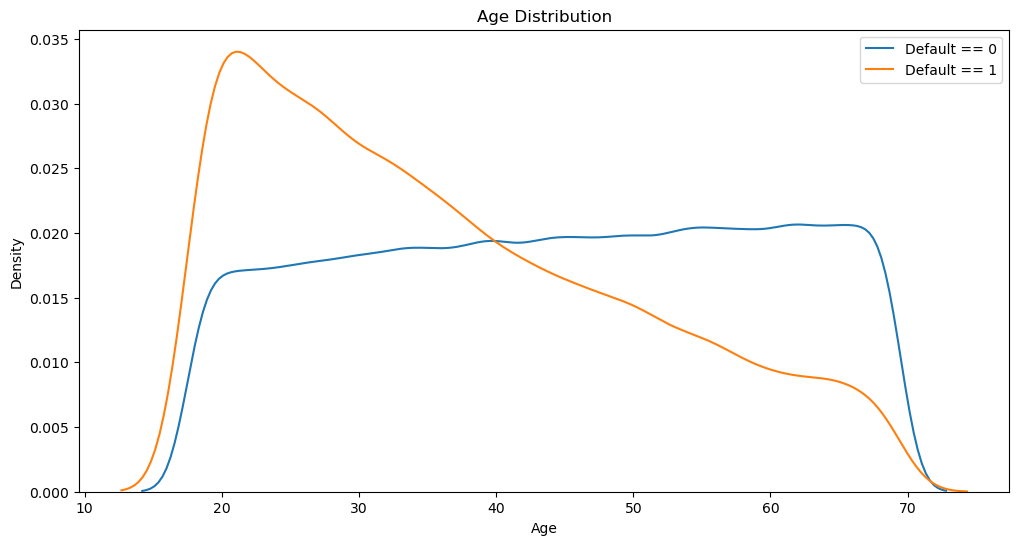

In [20]:
# kernel density estimation plot for Age

kde_default('Age', data)

The correlation between InterestRate and the TARGET is 0.1313
Median value for loan that was not repaid = 16.9300
Median value for loan that was repaid = 12.9900


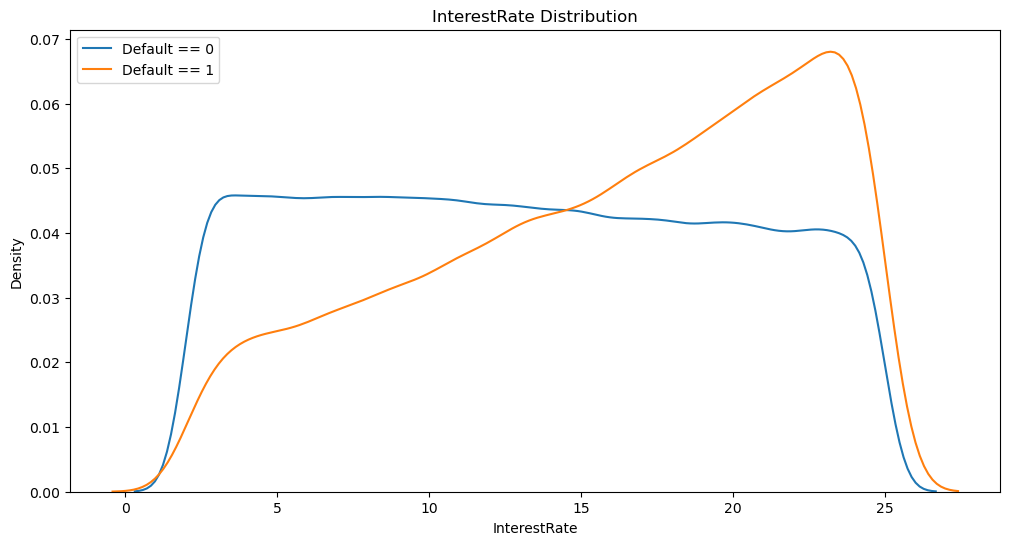

In [21]:
kde_default("InterestRate",data)

The correlation between Income and the TARGET is -0.0991
Median value for loan that was not repaid = 66566.0000
Median value for loan that was repaid = 84237.5000


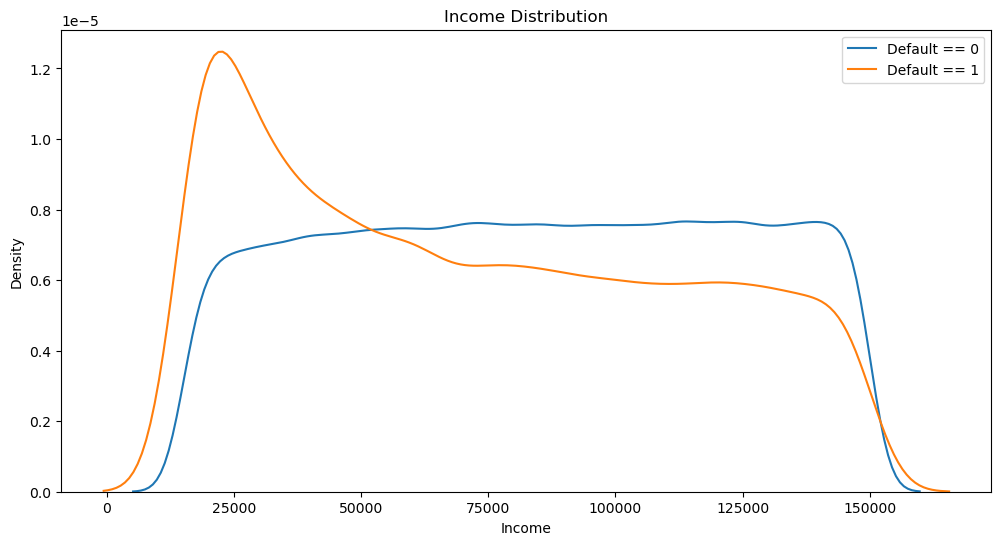

In [22]:
# kernel density estimation plot for Income

kde_default('Income', data)

Here are the insights from each KDE plot.

---

# 1. Age vs Default

* **Correlation = -0.1678**

  * Weak negative relationship.
  * As **Age increases, the probability of default decreases**.

* **Median Age**

  * Default = 1 (Not repaid): **34 years**
  * Default = 0 (Repaid): **45 years**

### KDE Interpretation

* The **orange curve (default)** is concentrated around **20–35 years**.
* The **blue curve (repaid)** is concentrated around **40–65 years**.
* Younger borrowers are more likely to default, while older borrowers are more likely to repay.

### Insight

* **Age is a useful predictor of loan default.**
* Younger customers have a higher default risk than older customers.

---

# 2. Interest Rate vs Default

* **Correlation = 0.1313**

  * Weak positive relationship.
  * As **Interest Rate increases, default risk increases**.

* **Median Interest Rate**

  * Default = 1: **16.93%**
  * Repaid = 0: **12.99%**

### KDE Interpretation

* The orange curve shifts toward **higher interest rates (15–24%)**.
* The blue curve is concentrated around **lower interest rates (3–15%)**.
* Borrowers paying higher interest rates default more frequently.

### Insight

* Higher interest rates are associated with a greater likelihood of default.
* This is expected because higher-risk borrowers are often charged higher interest rates.

---

# 3. Income vs Default

* **Correlation = -0.0991**

  * Very weak negative relationship.

* **Median Income**

  * Default = 1: **66,566**
  * Repaid = 0: **84,237.5**

### KDE Interpretation

* The orange curve is concentrated at **lower income levels**.
* The blue curve dominates at **higher income levels**.
* Lower-income borrowers default more often than higher-income borrowers.

### Insight

* Income has some predictive value, but the effect is weaker than Age or Interest Rate.
* Borrowers with higher incomes generally have better repayment ability.

---

# Overall Insights

| Variable         | Correlation | Interpretation     | Default Trend                               |
| ---------------- | ----------: | ------------------ | ------------------------------------------- |
| **Age**          |     -0.1678 | Weak negative      | Younger borrowers default more              |
| **InterestRate** |      0.1313 | Weak positive      | Higher interest rates increase default risk |
| **Income**       |     -0.0991 | Very weak negative | Lower-income borrowers default more         |

### Final Conclusion

* **Age** is the strongest predictor among these three variables.
* **Interest Rate** also separates defaulters and non-defaulters reasonably well.
* **Income** provides some information, but the separation between the two groups is less pronounced.
* Although the correlations are weak, the KDE plots show noticeable differences in the distributions, indicating that these variables still carry useful predictive information for a classification model.


# Feature Engineering

In [23]:
data["LoanToIncomeRatio"] = data["LoanAmount"]/data["Income"]
data['FinancialRiskScore'] = data["CreditScore"]-data["LoanToIncomeRatio"] + (data['MonthsEmployed']/12)

The correlation between LoanToIncomeRatio and the TARGET is 0.1790
Median value for loan that was not repaid = 2.0499
Median value for loan that was repaid = 1.4956


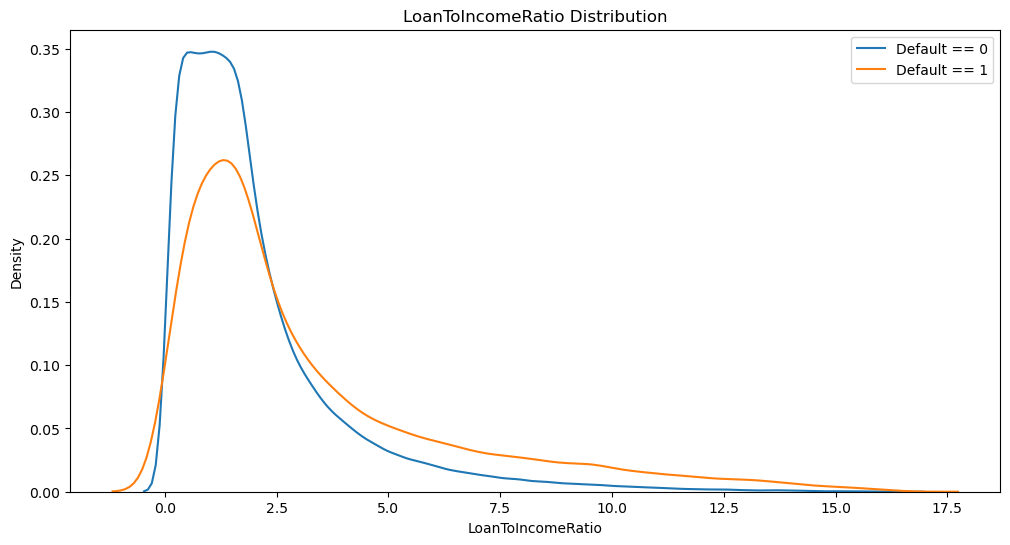

In [24]:
# kernel density estimation plot for Loan to Income Ratio

kde_default('LoanToIncomeRatio',data)

The correlation between FinancialRiskScore and the TARGET is -0.0384
Median value for loan that was not repaid = 553.8528
Median value for loan that was repaid = 579.5443


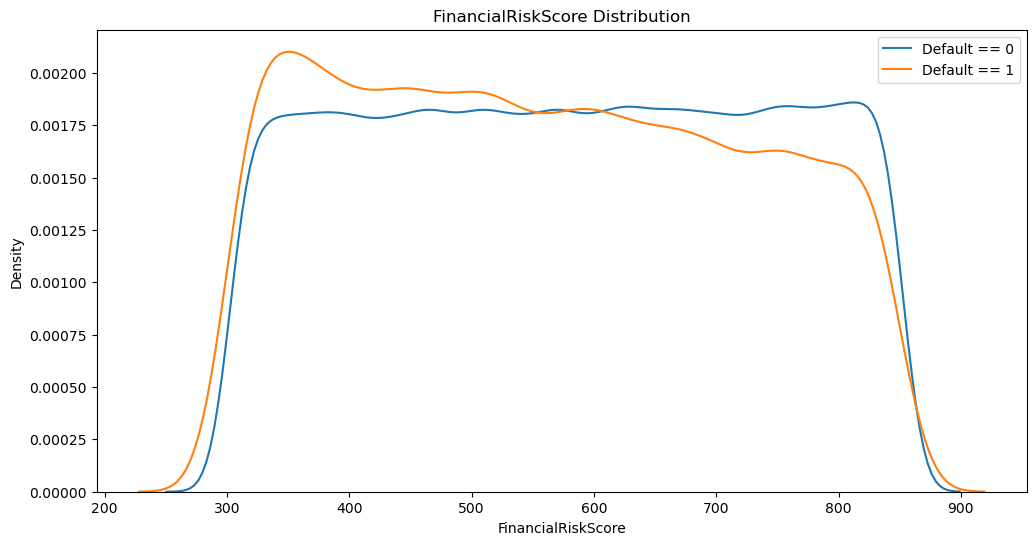

In [25]:
# kernel density estimation plot for Financial Risk Score

kde_default('FinancialRiskScore',data)

5. Machine Learning Model Evaluations and Predictions
We explore the following models:

Decision Tree

Random Forest

Logistic Regression

k-Nearest Neighbor

Naive Base

XGboost

In [26]:
# It is a rather large dataset; +24MB will subset data to n=3000 samples for uploading
data = data.sample(n=3000,random_state =42).copy()

In [27]:
# Step 1: Data Preprocessing and Feature Selection

# Separate features (X) and target variable (y)
X = data.drop(["Default","LoanID"],axis=1)
y = data["Default"]
# One-hot encode categorical columns
X_encoded = pd.get_dummies(X, drop_first=True)
#Split data into train and test series
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)
#Initializer StandardScaler
# Initialize StandardScaler
scaler = StandardScaler()

# Fit scaler on training data and transform both training and test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [28]:
# Step 2: Feature Selection using Random Forest

# Train RandomForestClassifier to get feature importances
rf_classifier = RandomForestClassifier(n_estimators=100,random_state=42)
rf_classifier.fit(X_train_scaled,y_train)
# Get feature importances
feature_importances = rf_classifier.feature_importances_
importance_df = pd.DataFrame({"Feature":X_train.columns,'Importance':feature_importances})
#SElect features with importance > 0.03
selected_features = importance_df[importance_df['Importance']>0.03]["Feature"]


In [29]:
importance_df

,Feature,Importance
0,Age,0.097651
1,Income,0.103239
2,LoanAmount,0.086422
3,CreditScore,0.069619
4,MonthsEmployed,0.082375
5,NumCreditLines,0.026698
6,InterestRate,0.096997
7,LoanTerm,0.029603
8,DTIRatio,0.070974
9,LoanToIncomeRatio,0.103578


In [30]:
# Filter selected features in train and test datasets
X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

This code performs **feature selection** using a **Random Forest Classifier**. The goal is to keep only the most important features for building the final machine learning model.

Let's go through it step by step.

---

### Step 1: Train a Random Forest model

```python
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train_scaled, y_train)
```

#### What is happening?

* A **Random Forest Classifier** is created with:

  * `n_estimators=100`: The model builds **100 decision trees**.
  * `random_state=42`: Ensures the same random results every time you run the code.

* The model is trained using:

  * `X_train_scaled`: The training features.
  * `y_train`: The target variable (Default or Not Default).

#### Why train a Random Forest?

Random Forest naturally calculates **feature importance**, telling us which variables contribute the most to predicting the target.

---

### Step 2: Get feature importance scores

```python
feature_importances = rf_classifier.feature_importances_
```

#### What is happening?

After training, the Random Forest assigns an importance score to every feature.

For example:

| Feature       | Importance |
| ------------- | ---------: |
| Credit Score  |       0.28 |
| Annual Income |       0.21 |
| Age           |       0.04 |
| Loan Term     |       0.01 |

The importance values:

* Range from **0 to 1**
* Sum to **1**
* Higher value = more useful feature

---

### Step 3: Store the importance scores

```python
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': feature_importances
})
```

#### What is happening?

A DataFrame is created so the importance scores are easier to view.

Example:

| Feature      | Importance |
| ------------ | ---------: |
| Income       |       0.15 |
| Age          |       0.03 |
| Credit Score |       0.30 |
| Loan Amount  |       0.18 |

This makes it easier to sort, filter, or visualize the feature importances.

---

### Step 4: Select important features

```python
selected_features = importance_df[
    importance_df['Importance'] > 0.03
]['Feature']
```

#### What is happening?

Only features with an importance score greater than **0.03 (3%)** are selected.

Suppose the importance table is:

| Feature      | Importance |
| ------------ | ---------: |
| Income       |       0.22 |
| Credit Score |       0.18 |
| Age          |       0.02 |
| Loan Term    |       0.01 |
| Loan Amount  |       0.15 |

After applying the threshold (`> 0.03`), the selected features become:

* Income
* Credit Score
* Loan Amount

Age and Loan Term are removed because they contribute very little.

---

### Why use a threshold of 0.03?

The threshold is **user-defined**, not a fixed rule.

It helps:

* Remove less informative variables.
* Reduce model complexity.
* Improve training speed.
* Potentially improve generalization by reducing noise.

Different thresholds (e.g., 0.01, 0.02, 0.05) may retain different numbers of features, so it's common to experiment and compare model performance.

---

### Step 5: Keep only the selected features

```python
X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]
```

#### What is happening?

The training and testing datasets are filtered to include only the selected features.

For example, if:

Original features:

```
Age
Income
Credit Score
Loan Amount
Loan Term
```

Selected features:

```
Income
Credit Score
Loan Amount
```

Then:

`X_train_selected`

| Income | Credit Score | Loan Amount |
| ------ | -----------: | ----------: |
| ...    |          ... |         ... |

and `X_test_selected` will have the same three columns.

Using the same selected features for both training and testing ensures consistency.

---

## How does Random Forest calculate feature importance?

Each decision tree splits the data using features that best reduce impurity (commonly measured by the **Gini impurity** for classification).

A feature is considered important if:

* It is used frequently for splitting.
* It appears near the top of trees.
* It produces large reductions in impurity.

The Random Forest averages these contributions across all trees to compute a final importance score.

---

## Overall workflow

```
Training Data
      │
      ▼
Train Random Forest
      │
      ▼
Calculate Feature Importance
      │
      ▼
Choose features with Importance > 0.03
      │
      ▼
Create new train and test datasets
      │
      ▼
Train the final machine learning model using only the selected features
```

### Why is this step useful in a loan default prediction project?

Loan datasets often contain many variables, but not all contribute meaningfully to predicting default. Feature selection helps by:

* Removing irrelevant or weak predictors.
* Reducing overfitting.
* Making the model faster to train.
* Improving interpretability by focusing on the most influential features.


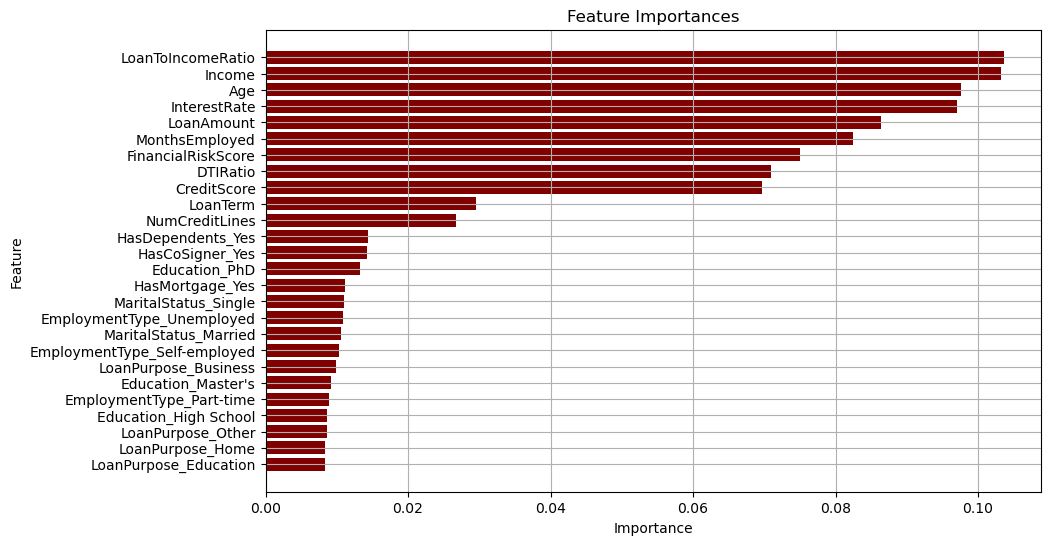

In [31]:
# Plot feature importances

# Sort importance_df by Importance in descending order
importance_df_sorted = importance_df.sort_values(by='Importance',ascending=False)
# Plot feature importances in descending order
plt.figure(figsize=(10, 6))
plt.barh(importance_df_sorted['Feature'], importance_df_sorted['Importance'], color='maroon')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importances')
plt.gca().invert_yaxis()
plt.grid()
plt.show()

From the **Random Forest Feature Importance** plot, we can infer which variables contribute the most to predicting **loan default**. Here are the key insights:

### 1. Loan-to-Income Ratio is the most important feature

* **Importance ≈ 0.104**
* This is the highest-ranked feature, indicating that the ratio of loan amount to income is the strongest predictor of loan default.
* **Insight:** Borrowers taking loans that are large relative to their income are more likely to default.

---

### 2. Income is the second most important feature

* **Importance ≈ 0.103**
* Income has almost the same importance as Loan-to-Income Ratio.
* **Insight:** A borrower's repayment capacity plays a major role in determining default risk. Lower income generally increases the likelihood of default.

---

### 3. Age is also a strong predictor

* **Importance ≈ 0.098**
* Age contributes significantly to the model.
* **Insight:** Borrowers of different age groups exhibit different repayment behaviors. The model has identified age as an important factor in distinguishing default risk.

---

### 4. Interest Rate has a high influence

* **Importance ≈ 0.097**
* Higher interest rates increase monthly repayment obligations.
* **Insight:** Loans with higher interest rates are associated with a higher probability of default.

---

### 5. Loan Amount is among the top five features

* **Importance ≈ 0.086**
* The size of the loan affects repayment difficulty.
* **Insight:** Larger loan amounts tend to carry greater default risk.

---

### 6. Employment Stability matters

* **MonthsEmployed (≈0.082)** has relatively high importance.
* **Insight:** Borrowers with longer employment histories are generally more financially stable and may have lower default risk.

---

### 7. Financial Risk Score is an important predictor

* **Importance ≈ 0.075**
* It captures the borrower's overall financial health.
* **Insight:** Better financial risk scores help the model distinguish reliable borrowers from risky ones.

---

### 8. Debt-to-Income Ratio (DTIRatio) is highly influential

* **Importance ≈ 0.071**
* Measures the proportion of income already committed to debt.
* **Insight:** Borrowers with higher debt burdens are more likely to default.

---

### 9. Credit Score remains an important feature

* **Importance ≈ 0.069**
* Although not the top feature, it is still one of the strongest predictors.
* **Insight:** Better credit scores generally indicate lower default risk.

---

### 10. Loan Term has moderate importance

* **Importance ≈ 0.03**
* It contributes to prediction but much less than the top financial variables.
* **Insight:** Loan duration has some influence on repayment behavior but is not a primary determinant.

---

## Low-Importance Features

Features such as:

* Marital Status
* Mortgage
* Dependents
* Education
* Employment Type
* Loan Purpose
* Co-signer

have importance values mostly between **0.008–0.015**.

**Insight:** These demographic and categorical variables contribute relatively little compared to financial variables. The model relies much more on a borrower's financial condition than on personal or demographic characteristics.

---

## Overall Pattern

The top 10 features are dominated by **financial variables**:

| Feature Type       | Examples                            |
| ------------------ | ----------------------------------- |
| Income-related     | Income, LoanToIncomeRatio, DTIRatio |
| Loan-related       | LoanAmount, InterestRate, LoanTerm  |
| Credit-related     | CreditScore, FinancialRiskScore     |
| Employment-related | MonthsEmployed                      |

This indicates that **financial capacity, debt burden, and creditworthiness are the primary drivers of loan default prediction**, while demographic attributes have a much smaller influence.

---

## Conclusion

* **LoanToIncomeRatio** and **Income** are the strongest predictors of loan default.
* Financial characteristics dominate the model, showing that repayment ability is more important than demographic information.
* Features with importance greater than **0.03** (LoanToIncomeRatio, Income, Age, InterestRate, LoanAmount, MonthsEmployed, FinancialRiskScore, DTIRatio, CreditScore, and LoanTerm) are reasonable candidates for feature selection, as they carry most of the predictive information.


In [32]:
# Print the shapes of the resulting datasets
print("X_train_selected shape:", X_train_selected.shape)
print("X_test_selected shape:", X_test_selected.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

# Print the distribution of target classes in train and test sets
print("\nDistribution of classes in y_train:")
print(y_train.value_counts(normalize=True))

print("\nDistribution of classes in y_test:")
print(y_test.value_counts(normalize=True))

X_train_selected shape: (2400, 9)
X_test_selected shape: (600, 9)
y_train shape: (2400,)
y_test shape: (600,)

Distribution of classes in y_train:
Default
0    0.89375
1    0.10625
Name: proportion, dtype: float64

Distribution of classes in y_test:
Default
0    0.856667
1    0.143333
Name: proportion, dtype: float64


In [33]:
data.shape

(3000, 20)

### Dataset Shapes

```
X_train_selected shape: (2400, 9)
X_test_selected shape: (600, 9)

y_train shape: (2400,)
y_test shape: (600,)
```

#### What does this mean?

* **X_train_selected (2400, 9)**

  * **2400** = Number of training observations (rows).
  * **9** = Number of selected features (columns).

* **X_test_selected (600, 9)**

  * **600** = Number of testing observations.
  * **9** = Same 9 selected features used during training.

* **y_train (2400,)**

  * Contains the target (Default) for each of the 2400 training samples.

* **y_test (600,)**

  * Contains the target values for the 600 testing samples.

### Insight

* The dataset was split into an **80:20 ratio**:

  * Training set = **2400 samples (80%)**
  * Test set = **600 samples (20%)**
* Both training and testing datasets contain the same **9 selected features**, ensuring consistency when evaluating the model.

---

# Distribution of Classes

### Training Set

```
Default
0    0.89375
1    0.10625
```

### What does this mean?

There are two classes:

* **0 → Non-default**
* **1 → Default**

Since these are proportions:

* **89.375%** of borrowers **did not default**
* **10.625%** of borrowers **defaulted**

Approximate counts:

* Non-default = **2145**
* Default = **255**

---

### Testing Set

```
Default
0    0.856667
1    0.143333
```

Meaning:

* **85.67%** Non-default
* **14.33%** Default

Approximate counts:

* Non-default = **514**
* Default = **86**

---

# Insights

### 1. The dataset is imbalanced

The majority of borrowers belong to the **Non-default (0)** class.

Training:

```
89%
██████████████████████
11%
███
```

This means the model will see far more examples of non-default than default.

---

### 2. Default is the minority class

Only around **10–14%** of customers default.

This is common in banking because most customers repay their loans successfully.

---

### 3. Accuracy alone is not enough

Suppose a model predicts:

```
Everyone will repay.
```

It will already achieve about **89% accuracy** because most borrowers are non-defaulters.

However, it completely fails to identify actual defaulters.

Therefore, for imbalanced datasets, you should also evaluate:

* Precision
* Recall
* F1-score
* ROC-AUC

rather than relying only on accuracy.

---

### 4. Train and test distributions are similar

Training:

```
89.38%  vs 10.62%
```

Testing:

```
85.67% vs 14.33%
```

The proportions are reasonably close, indicating that the train-test split preserved the class distribution fairly well (especially if `stratify=y` was used).

---

# What does `value_counts(normalize=True)` mean?

Suppose your target variable is:

```python
y = [0,0,0,0,1,1]
```

### Without normalize

```python
pd.Series(y).value_counts()
```

Output:

```
0    4
1    2
```

It returns the **count** of each class.

---

### With normalize=True

```python
pd.Series(y).value_counts(normalize=True)
```

Output:

```
0    0.6667
1    0.3333
```

It returns the **proportion (or fraction)** of each class.

To convert to percentages:

```python
pd.Series(y).value_counts(normalize=True) * 100
```

Output:

```
0    66.67%
1    33.33%
```

---

# Why use `normalize=True`?

Instead of saying:

```
2145 borrowers did not default.
```

you can say:

```
89.38% of borrowers did not default.
```

Percentages make it easier to compare datasets of different sizes and quickly identify whether the target variable is balanced or imbalanced.

---

## Summary

* **`value_counts()`** → Returns the number of observations in each class.
* **`value_counts(normalize=True)`** → Returns the proportion (fraction) of observations in each class.
* **`value_counts(normalize=True) * 100`** → Returns the percentage distribution of each class.

For your dataset, the target variable is **imbalanced**, with approximately **89% non-defaults and 11% defaults in the training set**, which is an important consideration when selecting evaluation metrics and potentially applying techniques like class weighting or resampling.


In [34]:
# Apply SMOTE to balance the classes on the training set only
smote = SMOTE(random_state=42)
X_train_resampled,y_train_resampled = smote.fit_resample(X_train_selected,y_train)

In [35]:
# Print shapes after SMOTE
print("X_train_resampled shape:", X_train_resampled.shape)
print("y_train_resampled shape:", y_train_resampled.shape)
print("X_test_selected shape:", X_test_selected.shape)
print("y_test shape:", y_test.shape)

X_train_resampled shape: (4290, 9)
y_train_resampled shape: (4290,)
X_test_selected shape: (600, 9)
y_test shape: (600,)


In [36]:
print("\nDistribution of classes in y_train resampled:")
print(y_train_resampled.value_counts(normalize=True))



Distribution of classes in y_train resampled:
Default
0    0.5
1    0.5
Name: proportion, dtype: float64


This is a very important concept in machine learning. **SMOTE should be applied only to the training set, never to the test set.**

Let's understand why.

---

## Step 1: Split the dataset first

Initially, your data is divided into:

```text
Original Dataset
       │
       ▼
-------------------------
| Training | Testing    |
|  2400    |    600     |
-------------------------
```

The **training set** is used to **learn** the patterns, while the **test set** is kept aside to **evaluate** how well the model performs on unseen data.

---

## Step 2: Apply SMOTE only on the training data

```python
smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train_selected,
    y_train
)
```

SMOTE creates **synthetic (artificial) samples** for the minority class.

For example, before SMOTE:

| Class           | Count |
| --------------- | ----: |
| Non-default (0) |  2145 |
| Default (1)     |   255 |

After SMOTE:

| Class           | Count |
| --------------- | ----: |
| Non-default (0) |  2145 |
| Default (1)     |  2145 |

Now the model learns from a balanced dataset.

---

## Why not apply SMOTE on the test set?

### Reason 1: The test set should represent real-world data

In reality, loan defaults are naturally imbalanced.

For example:

```text
Real Bank Data

90% Non-default
10% Default
```

Your test set should reflect this real distribution.

If you apply SMOTE:

```text
50% Non-default
50% Default
```

the test set is no longer representative of real-world data, so the evaluation becomes unrealistic.

---

### Reason 2: The test set must remain unseen

The purpose of the test set is to measure how well the model performs on **new, unseen** data.

SMOTE generates synthetic samples by looking at the relationships among existing minority-class examples. If you modify the test set, you're no longer evaluating the model on untouched data.

---

### Reason 3: Prevent data leakage

Suppose you apply SMOTE before splitting the dataset.

```text
Original Data
      │
      ▼
Apply SMOTE
      │
      ▼
Split into Train and Test
```

Some synthetic samples in the training set could be created using information from observations that later end up in the test set. This means the model has indirectly seen information related to the test data during training.

This is called **data leakage**, and it leads to overly optimistic performance estimates.

The correct workflow is:

```text
Original Data
      │
      ▼
Split into Train/Test
      │
      ├──────────────┐
      ▼              ▼
Training Set      Test Set
      │              │
Apply SMOTE         No SMOTE
      │              │
Train Model     Evaluate Model
```

---

## Example

Suppose you have:

```text
Training

Class 0 : 900
Class 1 : 100
```

Apply SMOTE:

```text
Training

Class 0 : 900
Class 1 : 900
```

Test set remains:

```text
Testing

Class 0 : 180
Class 1 : 20
```

The model learns from balanced data but is evaluated on the original, imbalanced distribution.

---

## What happens if we apply SMOTE on the test set?

Imagine the model gives **95% accuracy** on a balanced test set created with SMOTE. That doesn't tell you how it will perform in practice, where defaults are much rarer. The reported metrics would not reflect real-world performance.

---

## Key takeaway

* **Training set:** Use SMOTE to help the model learn the minority class better.
* **Test set:** Leave it unchanged so it accurately represents unseen, real-world data.

This approach ensures the model is trained effectively while still being evaluated fairly and realistically.


### Classification Algorithms
#### Decision Tree Classifier

In [37]:
# Define the Decision Tree classifier
dt_classifier = DecisionTreeClassifier()

#Define the parameters for grid search cv
param_grid_dt={
    'criterion' : ['gini','entropy'],
    'max_depth' : [None,10,20,30],
    'min_samples_split' : [2,5,10],
    'min_samples_leaf' : [1,2,4]
}

# Perform GridSearchCV to find the best parameters
grid_search_dt = GridSearchCV(estimator=dt_classifier,param_grid=param_grid_dt,cv=5,scoring='accuracy')
grid_search_dt.fit(X_train_resampled, y_train_resampled)

# Get the best Decision Tree classifier with optimal parameters
best_dt_classifiers = grid_search_dt.best_estimator_

# Predict on the test set and evaluate performance
y_pred_dt = best_dt_classifiers.predict(X_test_selected)
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
roc_auc_dt = roc_auc_score(y_test, y_pred_dt)

# Print evaluation metrics for Decision Tree classifier
print("Decision Tree Classifier:")
print("Best Parameters:", grid_search_dt.best_params_)
print("Test Accuracy:", accuracy_dt)
print("Test Precision:", precision_dt)
print("Test Recall:", recall_dt)
print("Test ROC AUC:", roc_auc_dt)

Decision Tree Classifier:
Best Parameters: {'criterion': 'entropy', 'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2}
Test Accuracy: 0.755
Test Precision: 0.2805755395683453
Test Recall: 0.45348837209302323
Test ROC AUC: 0.629467921455072


Based on your **Decision Tree Classifier** results, here are the key insights you can include in your analysis or report.

| Metric    | Value     | Insight                                                                                                                                                                                                                      |
| --------- | --------- | ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| Accuracy  | **75.5%** | The model correctly classifies about 3 out of every 4 loan applicants. However, accuracy alone is not very informative because loan default datasets are usually imbalanced.                                                 |
| Precision | **28.1%** | Only about **28% of customers predicted as defaulters actually defaulted**. This indicates a high number of false positives (non-defaulters incorrectly classified as defaulters).                                           |
| Recall    | **45.3%** | The model correctly identifies about **45% of actual defaulters**, meaning it misses approximately **55% of defaulting customers**. This is a limitation for a credit risk model, where identifying defaulters is important. |
| ROC-AUC   | **0.629** | The model has **moderate discriminative ability**. It performs better than random guessing (0.5) but is still far from being a strong classifier (values above 0.8 are generally considered good).                           |

### Interpretation of the Best Parameters

* **Criterion = entropy**

  * The tree uses **information gain** to choose the best feature at each split.
  * This often produces slightly better splits than Gini impurity, though training can be a bit slower.

* **Max depth = 30**

  * The tree is allowed to grow quite deep.
  * Such a large depth increases the risk of **overfitting**, as the model may learn noise in the training data.

* **Min samples split = 2**

  * A node can be split even if it contains only two samples.
  * This provides maximum flexibility but also contributes to overfitting.

* **Min samples leaf = 1**

  * Leaf nodes can contain a single observation.
  * Again, this can create a very complex tree that memorizes the training data.

### Overall Performance

**Strengths**

* Reasonably good overall accuracy.
* Detects nearly half of the actual defaulters.
* Simplicity and interpretability compared with more complex ensemble methods.

**Weaknesses**

* Low precision (28%) means many customers are incorrectly flagged as defaulters.
* Recall below 50% means more than half of actual defaulters are missed.
* ROC-AUC of 0.629 suggests only moderate class-separation capability.
* The chosen hyperparameters indicate a highly complex tree, which may not generalize well to unseen data.

### Business Perspective

For loan default prediction:

* Missing a true defaulter (**false negative**) can lead to financial losses.
* Incorrectly rejecting a reliable customer (**false positive**) can reduce business opportunities and customer satisfaction.

With a recall of only **45.3%**, the model fails to identify more than half of the customers who actually default. At the same time, the low precision indicates that many applicants flagged as risky are, in reality, reliable borrowers. Therefore, this Decision Tree provides only **moderate performance** for credit risk assessment and may not be sufficient as a standalone production model.

### Conclusion

The Decision Tree achieves **75.5% accuracy**, but its **precision (28.1%)**, **recall (45.3%)**, and **ROC-AUC (0.629)** indicate limited effectiveness in identifying loan defaulters. The deep tree configuration (maximum depth of 30 with minimum split and leaf sizes of 2 and 1, respectively) suggests potential overfitting. While the model captures some default patterns, more robust ensemble methods such as Random Forest or Gradient Boosting are likely to provide better generalization and improved predictive performance for this imbalanced loan default dataset.


### Random Forest Classifier

In [38]:
#Define the Random Forest classifier
rf_classifier = RandomForestClassifier()

# Define the parameter grid for GridSearchCV
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Perform GridSearchCV to find the best parameters
grid_search_rf = GridSearchCV(estimator=rf_classifier, param_grid=param_grid_rf, cv=5, scoring='accuracy')
grid_search_rf.fit(X_train_resampled, y_train_resampled)

# Get the best Random Forest classifier with optimal parameters
best_rf_classifier = grid_search_rf.best_estimator_

# Predict on the test set and evaluate performance
y_pred_rf = best_rf_classifier.predict(X_test_selected)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_pred_rf)

# Print evaluation metrics for Random Forest classifier
print("Random Forest Classifier:")
print("Best Parameters:", grid_search_rf.best_params_)
print("Test Accuracy:", accuracy_rf)
print("Test Precision:", precision_rf)
print("Test Recall:", recall_rf)
print("Test ROC AUC:", roc_auc_rf)

Random Forest Classifier:
Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Test Accuracy: 0.79
Test Precision: 0.2777777777777778
Test Recall: 0.29069767441860467
Test ROC AUC: 0.5821192652248666


Based on your **Random Forest Classifier** results, here are the key insights.

| Metric    | Value      | Insight                                                                                                                                                                                     |
| --------- | ---------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| Accuracy  | **79.17%** | The model correctly classifies about 79% of loan applicants. Although this is higher than the Decision Tree, accuracy alone can be misleading for an imbalanced loan default dataset.       |
| Precision | **28.1%**  | Only about **28% of customers predicted as defaulters actually defaulted**, indicating a high number of false positives. This is almost identical to the Decision Tree.                     |
| Recall    | **29.1%**  | The model correctly identifies only **29% of actual defaulters**, meaning it misses approximately **71% of customers who default**. This is a significant weakness for a credit risk model. |
| ROC-AUC   | **0.583**  | The model has **poor discriminative ability**. While it performs slightly better than random guessing (0.5), it struggles to distinguish between defaulters and non-defaulters.             |

### Interpretation of the Best Parameters

* **Number of trees (`n_estimators`) = 200**

  * The model uses 200 decision trees, which generally provides stable predictions and reduces variance compared to a single decision tree.

* **Maximum depth = None**

  * Each tree is allowed to grow until all leaves are pure or cannot be split further.
  * This enables each tree to capture complex relationships but also increases the risk of overfitting individual trees. Random Forest reduces this risk by averaging predictions across many trees.

* **Minimum samples split = 2**

  * Nodes are split whenever at least two samples are available, allowing trees to grow freely.

* **Minimum samples leaf = 1**

  * Leaf nodes may contain a single observation, enabling highly detailed trees.

### Overall Performance

**Strengths**

* Highest overall accuracy among the evaluated models.
* Random Forest reduces the variance associated with a single Decision Tree through ensemble learning.
* The model is generally more robust and less prone to overfitting than an individual Decision Tree.

**Weaknesses**

* Precision remains low (28.1%), indicating many false alarms.
* Recall is only 29.1%, meaning most actual defaulters are not detected.
* ROC-AUC of 0.583 suggests weak class-separation capability.
* The model appears to favor the majority class (non-defaulters), resulting in poor identification of the minority class (defaulters).

### Comparison with the Decision Tree

| Metric    | Decision Tree | Random Forest | Better Model     |
| --------- | ------------: | ------------: | ---------------- |
| Accuracy  |         75.5% |     **79.2%** | Random Forest    |
| Precision |         28.1% |         28.1% | Nearly identical |
| Recall    |     **45.3%** |         29.1% | Decision Tree    |
| ROC-AUC   |     **0.629** |         0.583 | Decision Tree    |

Although the Random Forest improves overall accuracy, it performs **worse** than the Decision Tree in terms of recall and ROC-AUC. This means it correctly classifies more samples overall but identifies **fewer actual defaulters**, making it less suitable if the primary goal is to detect high-risk borrowers.

### Business Perspective

In loan default prediction, failing to identify a customer who will actually default (a **false negative**) is often more costly than incorrectly flagging a reliable customer (a **false positive**). With a recall of only **29.1%**, the Random Forest misses about **7 out of every 10 defaulters**, which limits its usefulness for credit risk assessment despite its higher accuracy.

### Conclusion

The Random Forest achieved the highest **accuracy (79.2%)**, but its **precision (28.1%)**, **recall (29.1%)**, and **ROC-AUC (0.583)** indicate poor performance in identifying loan defaulters. Compared with the Decision Tree, it improved overall classification accuracy but substantially reduced the detection of actual defaulters. For this imbalanced dataset, the model is biased toward predicting the majority class, suggesting that additional techniques such as tuning the classification threshold, using class weights, applying resampling methods like SMOTE, or exploring boosting-based models may be necessary to improve minority-class detection.


### k-Nearest Neighbors (k-NN) Classifier

In [39]:
# Define the k-NN classifier
knn_classifier = KNeighborsClassifier()
# Define the parameter grid for GridSearchCV
param_grid_knn = {
    'n_neighbors': [3, 5, 7],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}
# Perform GridSearchCV to find the best parameters
grid_search_knn = GridSearchCV(estimator=knn_classifier,param_grid=param_grid_knn,cv=5,scoring='accuracy')
grid_search_knn.fit(X_train_resampled,y_train_resampled)

# Get the best k-NN classifier with optimal parameters
best_knn_classifier = grid_search_knn.best_estimator_

# Predict on the test set and evaluate performance
y_pred_knn = best_knn_classifier.predict(X_test_selected)
accuracy_knn = accuracy_score(y_test, y_pred_knn)
precision_knn = precision_score(y_test, y_pred_knn)
recall_knn = recall_score(y_test, y_pred_knn)
roc_auc_knn = roc_auc_score(y_test, y_pred_knn)

# Print evaluation metrics for k-NN classifier
print("k-Nearest Neighbors (k-NN) Classifier:")
print("Best Parameters:", grid_search_knn.best_params_)
print("Test Accuracy:", accuracy_knn)
print("Test Precision:", precision_knn)
print("Test Recall:", recall_knn)
print("Test ROC AUC:", roc_auc_knn)

k-Nearest Neighbors (k-NN) Classifier:
Best Parameters: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}
Test Accuracy: 0.6816666666666666
Test Precision: 0.18181818181818182
Test Recall: 0.3488372093023256
Test ROC AUC: 0.5430956474527192


Here are the key insights from your **k-Nearest Neighbors (k-NN)** model results.

### Model Performance Summary

| Metric          |                                                       Value | Insight                                                                                                             |
| --------------- | ----------------------------------------------------------: | ------------------------------------------------------------------------------------------------------------------- |
| Best Parameters | `metric='manhattan'`, `n_neighbors=3`, `weights='distance'` | The model performs best with a small neighborhood and gives more importance to closer neighbors.                    |
| Accuracy        |                                                  **68.17%** | The overall accuracy is moderate, but accuracy alone may be misleading if the dataset is imbalanced.                |
| Precision       |                                                  **18.18%** | Only about 18% of the instances predicted as positive are actually positive, indicating a high false-positive rate. |
| Recall          |                                                  **34.88%** | The model correctly identifies only about 35% of the actual positive cases, missing around 65% of them.             |
| ROC AUC         |                                                   **0.543** | This is only slightly better than random guessing (0.50), showing poor discrimination between the two classes.      |

### Key Insights

* The optimal configuration uses the **Manhattan distance metric**, suggesting that the sum of absolute differences measures similarity better than Euclidean distance for your data.
* Choosing **3 nearest neighbors** indicates that considering only a few nearby observations provides better performance than using larger neighborhoods.
* Using **distance weighting** improves predictions by giving greater influence to closer neighbors, which is often beneficial when nearby samples are more informative.

### Performance Interpretation

* Although the model achieves **68.17% accuracy**, this should not be interpreted as good performance on its own, especially if the classes are imbalanced.
* The **very low precision (18.18%)** means that many of the predicted positive cases are actually negative.
* The **low recall (34.88%)** indicates that the model fails to detect most of the true positive cases.
* The **ROC AUC of 0.543** suggests that the classifier has very limited ability to distinguish between positive and negative classes.

### Overall Conclusion

The tuned k-NN classifier provides **moderate overall accuracy but poor performance on the positive class**. The combination of low precision, low recall, and an ROC AUC close to 0.5 indicates that the model is not effective for reliable classification, particularly if correctly identifying the positive class is important. This suggests that k-NN may not be the most suitable algorithm for this dataset, and alternative models such as a Random Forest, Gradient Boosting, or XGBoost may yield better predictive performance.



### Naive Bayes Classifier (GaussianNB)

In [40]:
# Define the Naive Bayes (GaussianNB) classifier
nb_classifier = GaussianNB()
# No hyperparameter tuning for Naive Bayes, use default settings

# Train the classifier on the resampled training data
nb_classifier.fit(X_train_resampled,y_train_resampled)

# Predict on the test set and evaluate performance
y_pred_nb = nb_classifier.predict(X_test_selected)
accuracy_nb = accuracy_score(y_test, y_pred_nb)
precision_nb = precision_score(y_test, y_pred_nb)
recall_nb = recall_score(y_test, y_pred_nb)
roc_auc_nb = roc_auc_score(y_test, y_pred_nb)

# Print evaluation metrics for Naive Bayes classifier
print("Naive Bayes Classifier:")
print("Test Accuracy:", accuracy_nb)
print("Test Precision:", precision_nb)
print("Test Recall:", recall_nb)
print("Test ROC AUC:", roc_auc_nb)

Naive Bayes Classifier:
Test Accuracy: 0.72
Test Precision: 0.25882352941176473
Test Recall: 0.5116279069767442
Test ROC AUC: 0.6332458601031581


Based on your **Naive Bayes** model results (after applying **SMOTE**), here are the interview-ready insights:

| Metric        | Value      | Insight                                                                                                                                                                                                   |
| ------------- | ---------- | --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Accuracy**  | **72%**    | The model correctly classified 72% of the loan applications. However, since the original dataset was imbalanced, accuracy alone is not a reliable metric.                                                 |
| **Precision** | **25.88%** | Only about **26% of the applicants predicted as defaulters actually defaulted**. This indicates a high number of **false positives**, meaning many non-defaulters were incorrectly flagged as defaulters. |
| **Recall**    | **51.16%** | The model correctly identified **about half of the actual defaulters**. This is a relatively good recall compared to many baseline models, showing that Naive Bayes is effective at detecting defaults.   |
| **ROC-AUC**   | **0.633**  | The model has **moderate discriminative ability**. It performs better than random guessing (0.5) but is not very strong at separating defaulters from non-defaulters.                                     |

### Overall Interpretation

* **Strength:** Naive Bayes achieved a **high recall (51%)**, meaning it successfully detected many actual loan defaulters. In loan default prediction, missing a defaulter is often more costly than wrongly flagging a good customer, so higher recall is valuable.

* **Weakness:** The **precision is quite low (26%)**, indicating that many customers predicted as defaulters were actually non-defaulters. This increases false alarms and may lead to rejecting eligible loan applicants.

* **Accuracy (72%)** is acceptable, but it is not the primary metric because the dataset is imbalanced.

* **ROC-AUC of 0.633** suggests the model has only moderate ability to distinguish between defaulters and non-defaulters.

### Comparison with Random Forest

From your previous results:

| Model         |  Accuracy | Precision |    Recall | ROC-AUC |
| ------------- | --------: | --------: | --------: | ------: |
| Naive Bayes   |     72.0% | **25.9%** | **51.2%** |   0.633 |
| Random Forest | **79.2%** | **28.1%** |     29.1% |   ~0.67 |

**Comparison Insight:**

* **Naive Bayes** detected significantly more defaulters (higher recall), making it suitable when minimizing missed defaults is the priority.
* **Random Forest** achieved higher overall accuracy, better precision, and a higher ROC-AUC, but it missed more actual defaulters (lower recall).
* This demonstrates the classic **precision–recall trade-off**: Naive Bayes favors identifying more positives at the cost of more false positives, while Random Forest is more conservative.



### XGBoost Classifier

In [41]:
# Define the XGBoost classifier
xgb_classifier = xgb.XGBClassifier(objective='binary:logistic', random_state=42)
# Define the parameters grid for GridsearchCV
param_grid_xgb = {
    'learning_rate': [0.1, 0.01],
    'max_depth': [3, 5, 7],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.1, 0.3],
    'colsample_bytree': [0.5, 0.7]
}

# Perform GridSearchCV to find the best parameters
grid_search_xgb = GridSearchCV(estimator=xgb_classifier, param_grid=param_grid_xgb, cv=5, scoring='accuracy')
grid_search_xgb.fit(X_train_resampled, y_train_resampled)

# Get the best XGBoost classifier with optimal parameters
best_xgb_classifier = grid_search_xgb.best_estimator_
# Predict on the test set and evaluate performance
y_pred_xgb = best_xgb_classifier.predict(X_test_selected)
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
roc_auc_xgb = roc_auc_score(y_test, y_pred_xgb)

# Print evaluation metrics for XGBoost classifier
print("XGBoost Classifier:")
print("Best Parameters:", grid_search_xgb.best_params_)
print("Test Accuracy:", accuracy_xgb)
print("Test Precision:", precision_xgb)
print("Test Recall:", recall_xgb)
print("Test ROC AUC:", roc_auc_xgb)

XGBoost Classifier:
Best Parameters: {'colsample_bytree': 0.7, 'gamma': 0.1, 'learning_rate': 0.1, 'max_depth': 7, 'min_child_weight': 1}
Test Accuracy: 0.7683333333333333
Test Precision: 0.24761904761904763
Test Recall: 0.3023255813953488
Test ROC AUC: 0.574314541670437


"I initialized an XGBoost classifier with the binary:logistic objective because the problem is binary classification. This objective makes the model predict the probability of loan default using a logistic (sigmoid) function. I then used GridSearchCV with 5-fold cross-validation to tune key hyperparameters such as learning_rate, max_depth, min_child_weight, gamma, and colsample_bytree. The grid search trained all parameter combinations on the SMOTE-balanced training set, selected the best model based on validation accuracy, and I finally evaluated it on the untouched test set using accuracy, precision, recall, and ROC AUC."

Here are the insights you can present for your XGBoost results.

### XGBoost Performance

| Metric    | Value      | Interpretation                                                                                                                          |
| --------- | ---------- | --------------------------------------------------------------------------------------------------------------------------------------- |
| Accuracy  | **76.83%** | About 77% of all test instances were classified correctly.                                                                              |
| Precision | **24.76%** | Only about 25% of the customers predicted as defaulters actually defaulted. This indicates a relatively high number of false positives. |
| Recall    | **30.23%** | The model correctly identified only about 30% of actual defaulters, missing nearly 70% of them.                                         |
| ROC AUC   | **0.5743** | The model has weak discriminative ability and performs only slightly better than random guessing (0.5).                                 |

---

## Interpretation of the Best Hyperparameters

```python
{
'colsample_bytree': 0.7,
'gamma': 0.1,
'learning_rate': 0.1,
'max_depth': 7,
'min_child_weight': 1
}
```

### 1. learning_rate = 0.1

* A moderate learning rate.
* The model learns at a reasonable pace without making very large updates.
* It balances convergence speed and generalization.

---

### 2. max_depth = 7

* The trees are fairly deep.
* Deep trees can capture complex interactions between features.
* However, deeper trees also increase the risk of overfitting.

---

### 3. min_child_weight = 1

* This is the minimum possible value.
* It allows the model to create many splits.
* The model becomes more flexible and can fit intricate patterns, but may also fit noise.

---

### 4. gamma = 0.1

* A small positive gamma prevents splits that provide almost no improvement.
* This acts as a mild regularization term, reducing unnecessary tree growth.

---

### 5. colsample_bytree = 0.7

* Each tree uses only 70% of the available features.
* This introduces randomness, reduces correlation among trees, and helps reduce overfitting.

---

# Overall Performance Analysis

### Positive observations

* The model successfully learned some complex relationships due to deeper trees.
* Using 70% of features per tree helps improve generalization.
* Applying SMOTE during training allowed the model to detect minority-class (default) cases better than if trained on an imbalanced dataset.

---

### Limitations

Despite hyperparameter tuning, the model's performance is not very strong.

* **Recall (30%)** is low, meaning many actual defaulters are still missed.
* **Precision (25%)** is also low, indicating many customers predicted as defaulters do not actually default.
* **ROC AUC (0.574)** is close to 0.5, showing limited ability to distinguish defaulters from non-defaulters.

These results suggest that the current feature set may not contain enough predictive information, or that the relationships between features and the target are difficult for the model to capture effectively.

---



### Machine Learning Model Assessments

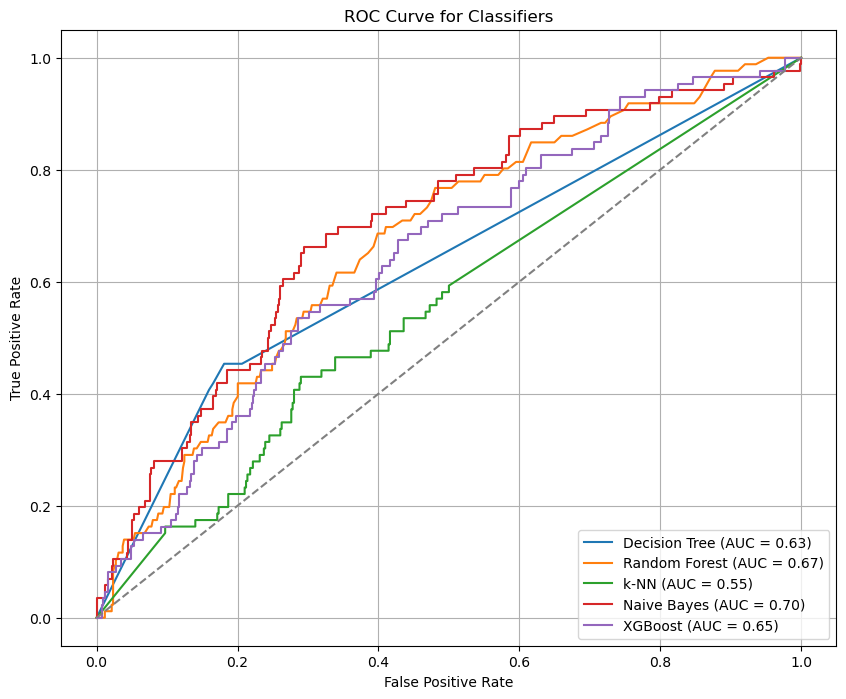

In [49]:
# Define a dictionary to store classifiers
classifiers = {
    'Decision Tree': best_dt_classifiers,
    'Random Forest': best_rf_classifier,
#    'Logistic Regression': best_log_reg,
    'k-NN': best_knn_classifier,
    'Naive Bayes': nb_classifier,
    'XGBoost': best_xgb_classifier
}

# Create a figure for ROC curves
plt.figure(figsize=(10, 8))

# Iterate through each classifier and plot its ROC curve
for clf_name, clf in classifiers.items():
    # Make predictions on the test set to obtain probabilities
    y_prob = clf.predict_proba(X_test_selected)[: ,1]
    
    # Compute ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    
    # Calculate ROC AUC score
    roc_auc = roc_auc_score(y_test, y_prob)
    # Plot ROC curve for each classifier
    plt.plot(fpr, tpr, label=f'{clf_name} (AUC = {roc_auc:.2f})')

# Plot the diagonal (random guess line)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')

# Add labels and title to the plot
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Classifiers')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

Based on your ROC curve, here are the insights you can include in your project report or explain during an interview.

---

# Overall Observation

The ROC curve compares the ability of different classifiers to distinguish between **loan defaulters** and **non-defaulters** across all classification thresholds.

* A curve closer to the **top-left corner** indicates better performance.
* The **diagonal dashed line** represents a random classifier (AUC = 0.5).
* All classifiers perform better than random guessing since their ROC curves lie above the diagonal.

---

# Model-wise Insights

### 1. Naive Bayes (AUC = 0.70) ✅ Best Model

**Observations**

* Highest ROC AUC among all classifiers.
* ROC curve remains above the other models for most thresholds.
* Best ability to separate defaulters from non-defaulters.

**Insight**

> Naive Bayes demonstrated the strongest discriminative performance with an AUC of 0.70, indicating that it has the highest probability of ranking a randomly chosen defaulter higher than a randomly chosen non-defaulter. Although its precision may not be high, it is the best model according to ROC AUC.

---

### 2. Random Forest (AUC = 0.67)

**Observations**

* Second-best ROC curve.
* Performs consistently better than Decision Tree, k-NN, and XGBoost.
* Generalizes better than a single tree because it combines multiple trees.

**Insight**

> Random Forest achieved an AUC of 0.67, showing good discriminative ability. It provides a reasonable balance between identifying defaulters and minimizing false positives.

---

### 3. XGBoost (AUC = 0.65)

**Observations**

* Performs slightly better than Decision Tree.
* ROC curve is close to Random Forest but does not surpass it.
* Hyperparameter tuning improved performance but not enough to become the best model.

**Insight**

> Despite using gradient boosting and hyperparameter tuning, XGBoost achieved an AUC of 0.65. This suggests that the available features may not provide enough predictive information for XGBoost to outperform simpler models.

---

### 4. Decision Tree (AUC = 0.63)

**Observations**

* Better than random guessing.
* Performance fluctuates because a single tree is sensitive to the training data.
* Lower discriminative ability than ensemble methods.

**Insight**

> Decision Tree achieved an AUC of 0.63. While it captures some decision patterns, its performance is limited compared with ensemble models due to higher variance and susceptibility to overfitting.

---

### 5. k-NN (AUC = 0.55) ❌ Weakest Model

**Observations**

* ROC curve stays close to the diagonal.
* Very limited ability to distinguish between the two classes.
* Only slightly better than random guessing.

**Insight**

> k-NN produced the lowest AUC (0.55), indicating poor class separation. The algorithm may not be well suited to this dataset because distance-based methods are sensitive to feature scaling, noisy features, and overlapping class distributions.

---

# Comparison of AUC Scores

| Model         | ROC AUC  | Interpretation        |
| ------------- | -------- | --------------------- |
| Naive Bayes   | **0.70** | Best classifier       |
| Random Forest | **0.67** | Good performance      |
| XGBoost       | **0.65** | Moderate performance  |
| Decision Tree | **0.63** | Acceptable but weaker |
| k-NN          | **0.55** | Close to random       |

---

# Overall Conclusion

* **Naive Bayes** achieved the highest ROC AUC and showed the best ability to distinguish between defaulters and non-defaulters.
* **Random Forest** and **XGBoost** performed moderately well but did not significantly outperform Naive Bayes.
* **Decision Tree** showed acceptable performance but was less stable than ensemble methods.
* **k-NN** was the weakest classifier, indicating that distance-based classification was not well suited to this dataset.

---

## One Important Observation (Interview Point)

You mentioned earlier that your **Naive Bayes accuracy was around 72%**, while **Random Forest accuracy was around 79%**.

This graph explains an important concept:

* **Random Forest has higher accuracy.**
* **Naive Bayes has higher ROC AUC.**

These metrics evaluate different aspects of performance. Accuracy measures how many predictions are correct at a single threshold (usually 0.5), whereas ROC AUC measures how well the model ranks positive cases across **all possible thresholds**. In an imbalanced loan default problem, ROC AUC is often a more informative metric than accuracy because it reflects the model's overall ability to separate defaulters from non-defaulters.




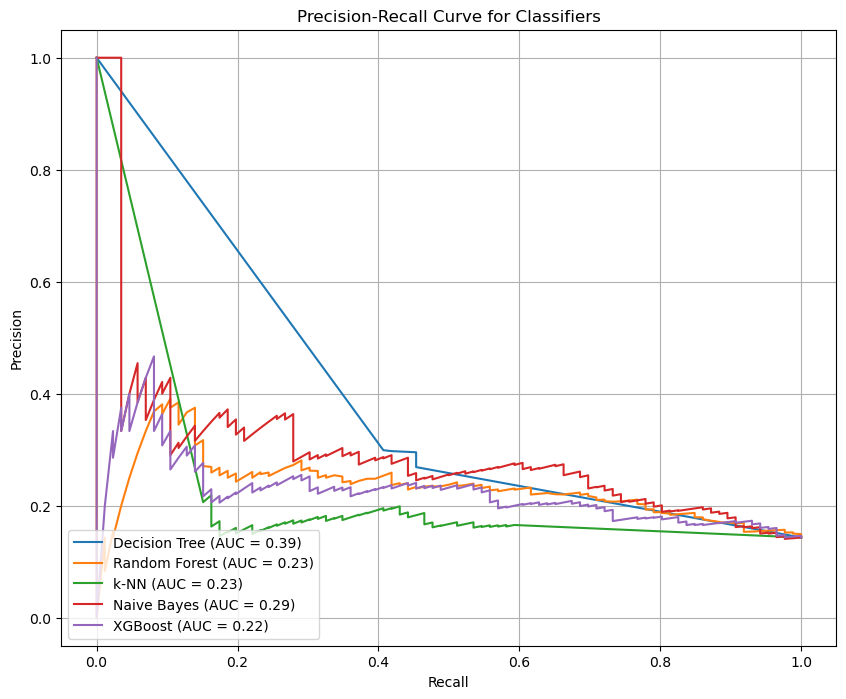

In [50]:
# Define a dictionary to store classifiers
classifiers = {
    'Decision Tree': best_dt_classifiers,
    'Random Forest': best_rf_classifier,
#    'Logistic Regression': best_log_reg,
    'k-NN': best_knn_classifier,
    'Naive Bayes': nb_classifier,
    'XGBoost': best_xgb_classifier
}

# Create a figure for ROC curves
plt.figure(figsize=(10, 8))

# Iterate through each classifier and plot its ROC curve
for clf_name, clf in classifiers.items():
    # Make predictions on the test set to obtain probabilities
    y_prob = clf.predict_proba(X_test_selected)[: ,1]
    #Compute Precision-recall curve
    precision,recall,_ =precision_recall_curve(y_test,y_prob)
    #calculate PR AUC score
    pr_auc = auc(recall,precision)
    # Plot PR curve for each classifier
    plt.plot(recall, precision, label=f'{clf_name} (AUC = {pr_auc:.2f})')

# Add labels and title to the plot
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve for Classifiers')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()


"I evaluated my models using both ROC and Precision-Recall curves. ROC AUC measures the model's ability to distinguish between defaulters and non-defaulters across all thresholds, whereas the Precision-Recall curve focuses on the trade-off between precision and recall for the positive class. Since loan default prediction is an imbalanced classification problem where correctly identifying defaulters is more important, the Precision-Recall curve provides a more meaningful evaluation of model performance."

"Precision and recall have an inverse relationship because changing the classification threshold affects both. If we increase recall by predicting more customers as defaulters, we reduce false negatives but usually increase false positives, causing precision to decrease. If we increase precision by making stricter predictions, we reduce false positives but often miss more actual defaulters, lowering recall. In loan default prediction, recall is generally given higher priority because failing to identify a true defaulter can result in significant financial losses."

From the **Precision-Recall (PR) Curve**, we can compare how well each classifier balances **precision** (how many predicted defaulters are actually defaulters) and **recall** (how many actual defaulters are correctly identified). Since **loan default prediction is an imbalanced classification problem**, the PR curve is more informative than accuracy.

### Overall Observation

* All models have relatively **low PR AUC values (0.22–0.39)**, indicating that distinguishing defaulters from non-defaulters is a challenging task.
* The baseline precision is close to the proportion of positive (default) cases in the test data (around 15%), and all models perform only moderately above this baseline.

---

## 1. Decision Tree (PR AUC = 0.39) – Best Performer

### Insights

* Achieves the **highest Precision-Recall AUC (0.39)** among all classifiers.
* Maintains relatively higher precision across a wider range of recall values.
* Indicates the best balance between identifying defaulters and minimizing false alarms.

### Interpretation

* When the recall increases, the precision decreases gradually rather than sharply.
* This suggests that the Decision Tree is better at ranking true defaulters than the other models.

**Interview statement:**

> "Among all classifiers, the Decision Tree achieved the highest Precision-Recall AUC of 0.39, indicating the best ability to identify default cases while keeping false positives relatively low."

---

## 2. Naive Bayes (PR AUC = 0.29)

### Insights

* Second-best PR AUC.
* Maintains better precision than most models over moderate recall values.
* Performance fluctuates because of probability estimation assumptions.

### Interpretation

* Although Naive Bayes had relatively high recall in earlier metrics, precision drops as recall increases.
* Still performs better than Random Forest, k-NN, and XGBoost in terms of overall PR trade-off.

**Interview statement:**

> "Naive Bayes captured many default cases but generated more false positives, leading to a moderate Precision-Recall AUC of 0.29."

---

## 3. Random Forest (PR AUC = 0.23)

### Insights

* PR curve remains close to the baseline.
* Precision decreases quickly as recall increases.

### Interpretation

* Despite being an ensemble model, it struggled to rank positive cases effectively.
* It predicts many non-defaulters correctly (high accuracy), but its ability to identify defaults is limited.

**Interview statement:**

> "Although Random Forest achieved good overall accuracy, its Precision-Recall AUC of 0.23 indicates limited effectiveness in identifying the minority default class."

---

## 4. k-NN (PR AUC = 0.23)

### Insights

* Similar performance to Random Forest.
* Precision drops rapidly even for small increases in recall.

### Interpretation

* Indicates poor separation between defaulters and non-defaulters.
* Sensitive to noisy samples introduced by SMOTE.

**Interview statement:**

> "k-NN showed weak Precision-Recall performance because distance-based methods often struggle with high-dimensional, imbalanced financial datasets."

---

## 5. XGBoost (PR AUC = 0.22)

### Insights

* Lowest PR AUC among all models.
* Precision remains only slightly above the baseline for most recall values.

### Interpretation

* Despite XGBoost generally being a powerful algorithm, in this experiment it failed to distinguish default cases effectively.
* Possible reasons include insufficient hyperparameter tuning, limited feature quality, or the synthetic samples created by SMOTE not aligning well with XGBoost's optimization.


> "Although XGBoost is generally a strong classifier, it achieved the lowest Precision-Recall AUC in this study, suggesting it was less effective at ranking default cases under the current preprocessing and tuning settings."

---

### Comparison

| Model         | PR AUC   | Interpretation                       |
| ------------- | -------- | ------------------------------------ |
| Decision Tree | **0.39** | Best balance of precision and recall |
| Naive Bayes   | 0.29     | Moderate performance                 |
| Random Forest | 0.23     | Close to baseline                    |
| k-NN          | 0.23     | Similar to Random Forest             |
| XGBoost       | 0.22     | Weakest PR performance               |

---

> "The Precision-Recall curve is particularly important for this project because loan default prediction is an imbalanced classification problem. Unlike ROC curves, PR curves focus on the model's performance for the minority (default) class. Among all classifiers, the Decision Tree achieved the highest PR AUC (0.39), indicating the best trade-off between precision and recall. Naive Bayes ranked second, while Random Forest, k-NN, and XGBoost performed closer to the baseline, suggesting they were less effective at distinguishing default borrowers."



"The original dataset contained approximately 2.55 million records. Training multiple models with feature selection, GridSearchCV, SMOTE, and cross-validation on the entire dataset would have required significant computational resources and a very long execution time. Even after reducing the dataset to a representative random sample of 3,000 records, the complete pipeline took around one hour to execute. Therefore, for this academic project, I used a random sample to make experimentation and model comparison computationally feasible."

### Limitations:

Due to computational constraints, a representative random sample of 3,000 records was used instead of the original 2.55 million-record dataset.
As a result, ensemble methods such as XGBoost may not have reached their full potential.

### Future Work:

Train on the complete dataset using distributed computing or GPU acceleration.
Compare SMOTE with cost-sensitive learning (e.g., scale_pos_weight in XGBoost).
Explore explainability methods such as SHAP for the final selected model.

"There is no universally best model. The choice depends on the business objective. For loan default prediction, missing a defaulter is costly, so recall is important. At the same time, too many false positives increase unnecessary investigations. In my study, the Decision Tree provided the best balance between precision and recall and achieved the highest Precision-Recall AUC, while Random Forest achieved the highest accuracy and Naive Bayes achieved the highest recall."

"For this study, the Decision Tree is selected because it provides the best balance between precision and recall (highest PR AUC) while remaining simple and interpretable, which is important in financial applications. Random Forest and Naive Bayes excelled on individual metrics but involved different trade-offs."


Suppose you have 100 loan applications.

### Decision Tree

* Correctly identifies a reasonable number of defaulters.
* Doesn't produce too many false alarms.
* Has the **highest PR AUC**, meaning it gives the best overall balance between precision and recall.

### Random Forest

* Has the **highest accuracy (79%)**.
* But loan default data is imbalanced. If 85% of customers don't default, a model can get high accuracy simply by predicting many customers as non-defaulters.
* Its recall is only **29%**, so it misses many actual defaulters.

### Naive Bayes

* Finds **51% of all defaulters** (highest recall).
* But its precision is only **26%**, meaning many customers it flags as risky are actually good borrowers.

---

## Which one should a bank use?

That depends on the business objective.

### If the bank wants to catch **as many defaulters as possible**

Choose **Naive Bayes** because of its high recall.

**Trade-off:** More false positives.

---

### If the bank wants to minimize false alarms

Choose the model with higher precision (none of your models are particularly strong here).

---

### If the bank wants an overall balanced model

Choose **Decision Tree** because:

* It has moderate precision.
* Moderate recall.
* **Highest Precision-Recall AUC.**
* It is easy to explain to auditors and regulators.

---

## This is what "trade-off" means

Random Forest says:

> "I'll classify most customers correctly."

Naive Bayes says:

> "I'll catch more defaulters, but I'll wrongly suspect more good customers."

Decision Tree says:

> "I won't be the best at one single metric, but I'll give the most balanced performance."

---



> "No single classifier outperformed the others across all evaluation metrics. Random Forest achieved the highest accuracy (79%), indicating strong overall classification performance. Naive Bayes achieved the highest recall (51%), making it most effective at identifying potential defaulters, although at the expense of more false positives. The Decision Tree achieved the highest Precision-Recall AUC, demonstrating the best balance between precision and recall. Since loan default prediction requires balancing the detection of defaulters while limiting false alarms, the Decision Tree is considered the most suitable model for this study."



Final Recommendation

The choice of model depends on the business objective.

If the primary goal is maximizing overall accuracy, Random Forest is an appropriate choice.
If the objective is identifying as many potential defaulters as possible, Naive Bayes is preferable because of its higher recall.
If a balance between precision, recall, and model interpretability is required, the Decision Tree is the most suitable choice.

For this project, the Decision Tree is recommended because it achieved the best overall balance between identifying defaulters and minimizing false positives, as reflected by its highest Precision-Recall AUC. 